In [1]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from scipy import stats
from scipy.stats import binomtest, f_oneway
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_curve, auc,
                              precision_recall_fscore_support)
from sklearn.utils import resample

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import copy

try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available()
                       else 'cpu')

DATA_DIR   = Path(r'C:\Users\moyth\Documents\ML_biowin\mat_machine_learning')
SCORES_XLS = Path(r'C:\Users\moyth\Documents\Biowin\Samia_BIOWIN_DBcomplete.xlsx')

N_BANDS    = 5       # delta, theta, alpha, beta1, beta2
N_CH       = 127     # electrodes 
N_COMP     = 50      # PCA components
                   
BAND_NAMES = ['delta', 'theta', 'alpha', 'beta', 'gamma']
CONDITIONS = ['REST', 'HYP', 'VRH']
LABEL_MAP  = {'REST': 0, 'HYP': 1, 'VRH': 2}

C_REST   = '#2C2C2A'
C_HYP    = '#534AB7'
C_VRH    = '#993C1D'
C_SHARED = '#0D7377'
C_GREEN  = '#2D6A4F'

MODEL_COLORS = {
    'SVM':         '#E74C3C',
    'LDA':         '#E67E22',
    'Rand Forest': '#F1C40F',
    'XGBoost':     '#27AE60',
    'MLP':         '#1ABC9C',
    'LSTM':        '#2980B9',
    'EEGNet':      C_HYP,
    'Transformer': C_VRH,
}
assert DATA_DIR.exists(),   f'DATA_DIR not found: {DATA_DIR}'
assert SCORES_XLS.exists(), f'SCORES_XLS not found: {SCORES_XLS}'

print(f'Device       : {device}')
print(f'PyTorch      : {torch.__version__}')
print(f'MAT files    : {len(list(DATA_DIR.glob("*.mat")))}')

Device       : cpu
PyTorch      : 2.11.0+cpu
MAT files    : 198


In [2]:
# File Registry & Data Loading
# bpower shape: (5, 127) 
#  bpower[b] = band b, all 127 channels
# matrix shape: (5, 127, 127) — dwPLI connectivity

FILE_REGISTRY = {
    (1,  'REST'): 'Subject_001_EO_mohawk.mat',
    (1,  'HYP'):  'Subject_001_Hyp_mohawk.mat',
    (1,  'VRH'):  'Subject_001_VRH_mohawk.mat',
    (2,  'REST'): 'Subject_002_EO_mohawk.mat',
    (2,  'HYP'):  'Subject_002_Hyp_mohawk.mat',
    (2,  'VRH'):  'Subject_002_VRH_mohawk.mat',
    (3,  'REST'): 'Subject_003_EO_mohawk.mat',
    (3,  'HYP'):  'Subject_003_Hyp_mohawk.mat',
    (3,  'VRH'):  'Subject_003_VRH_mohawk.mat',
    (4,  'REST'): 'Subject_004_EO_mohawk.mat',
    (4,  'HYP'):  'Subject_004_Hyp_mohawk.mat',
    (4,  'VRH'):  'Subject_004_VRH_mohawk.mat',
    (5,  'REST'): 'Subject_005_EO_mohawk.mat',
    (5,  'HYP'):  'Subject_005_Hyp_mohawk.mat',
    (5,  'VRH'):  'Subject_005_VRH_mohawk.mat',
    (6,  'REST'): 'Subject_006_EO_mohawk.mat',
    (6,  'HYP'):  'Subject_006_Hyp_mohawk.mat',
    (6,  'VRH'):  'Subject_006_VRH_mohawk.mat',
    (7,  'REST'): 'Subject_007_EO_mohawk.mat',
    (7,  'HYP'):  'Subject_007_Hyp_mohawk.mat',
    (7,  'VRH'):  'Subject_007_VRH_mohawk.mat',
    (8,  'REST'): 'Subject_008_EO_mohawk.mat',
    (8,  'HYP'):  'Subject_008_Hyp_mohawk.mat',
    (8,  'VRH'):  'Subject_008_VRH_mohawk.mat',
    (9,  'REST'): 'Subject_009_EO_mohawk.mat',
    (9,  'HYP'):  'Subject_009_Hyp_mohawk.mat',
    (9,  'VRH'):  'Subject_009_VRH_mohawk.mat',
    (10, 'REST'): 'Subject_010_EO_mohawk.mat',
    (10, 'HYP'):  'Subject_010_Hyp_mohawk.mat',
    (10, 'VRH'):  'Subject_010_VRH_mohawk.mat',
    (11, 'REST'): 'Subject_011_EO_mohawk.mat',
    (11, 'HYP'):  'Subject_011_Hyp_mohawk.mat',
    (11, 'VRH'):  'Subject_011_VRH_mohawk.mat',
    (12, 'REST'): 'Subject_012_EO_mohawk.mat',
    (12, 'HYP'):  'Subject_012_Hyp_mohawk.mat',
    (12, 'VRH'):  'Subject_012_VRH_mohawk.mat',
    (13, 'REST'): 'Subject_013_EO_mohawk.mat',
    (13, 'HYP'):  'Subject_013_Hyp_mohawk.mat',
    (13, 'VRH'):  'Subject_013_VRH_mohawk.mat',
    (14, 'REST'): 'Subject_014_EO_mohawk.mat',
    (14, 'HYP'):  'Subject_014_Hyp_mohawk.mat',
    (14, 'VRH'):  'Subject_014_VRH_mohawk.mat',
    (15, 'REST'): 'Subject_015_EO_mohawk.mat',
    (15, 'HYP'):  'Subject_015_Hyp_mohawk.mat',
    (15, 'VRH'):  'Subject_015_VRH_mohawk.mat',
    (16, 'REST'): 'Subject_016_EO_mohawk.mat',
    (16, 'HYP'):  'Subject_016_Hyp_mohawk.mat',
    (16, 'VRH'):  'Subject_016_VRH_mohawk.mat',
    (17, 'REST'): 'Subject_017_EO_mohawk.mat',
    (17, 'HYP'):  'Subject_017_Hyp_mohawk.mat',
    (17, 'VRH'):  'Subject_017_VRH_mohawk.mat',
    (18, 'REST'): 'Subject_018_EO_mohawk.mat',
    (18, 'HYP'):  'Subject_018_Hyp_mohawk.mat',
    (18, 'VRH'):  'Subject_018_VRH_mohawk.mat',
    (19, 'REST'): 'Subject_019_EO_mohawk.mat',
    (19, 'HYP'):  'Subject_019_Hyp_mohawk.mat',
    (19, 'VRH'):  'Subject_019_VRH_mohawk.mat',
    (20, 'REST'): 'Subject_020_EO_mohawk.mat',
    (20, 'HYP'):  'Subject_020_Hyp_mohawk.mat',
    (20, 'VRH'):  'Subject_020_VRH_mohawk.mat',
    (21, 'REST'): 'Subject_021_EO_mohawk.mat',
    (21, 'HYP'):  'Subject_021_Hyp_mohawk.mat',
    (21, 'VRH'):  'Subject_021_VRH_mohawk.mat',
    (22, 'REST'): 'Subject_022_EO_mohawk.mat',
    (22, 'HYP'):  'Subject_022_Hyp_mohawk.mat',
    (22, 'VRH'):  'Subject_022_VRH_mohawk.mat',
    (23, 'REST'): 'Subject_023_EO_mohawk.mat',
    (23, 'HYP'):  'Subject_023_Hyp_mohawk.mat',
    (23, 'VRH'):  'Subject_023_VRH_mohawk.mat',
    (24, 'REST'): 'Subject_024_EO_mohawk.mat',
    (24, 'HYP'):  'Subject_024_Hyp_mohawk.mat',
    (24, 'VRH'):  'Subject_024_VRH_mohawk.mat',
    (25, 'REST'): 'Subject_025_EO_mohawk.mat',
    (25, 'HYP'):  'Subject_025_Hyp_mohawk.mat',
    (25, 'VRH'):  'Subject_025_VRH_mohawk.mat',
    (26, 'REST'): 'Subject_026_EO_mohawk.mat',
    (26, 'HYP'):  'Subject_026_Hyp_mohawk.mat',
    (26, 'VRH'):  'Subject_026_VRH_mohawk.mat',
    (27, 'REST'): 'Subject_027_EO_mohawk.mat',
    (27, 'HYP'):  'Subject_027_Hyp_mohawk.mat',
    (27, 'VRH'):  'Subject_027_VRH_mohawk.mat',
    (28, 'REST'): 'Subject_028_EO_mohawk.mat',
    (28, 'HYP'):  'Subject_028_Hyp_mohawk.mat',
    (28, 'VRH'):  'Subject_028_VRH_mohawk.mat',
    (29, 'REST'): 'Subject_029_EO_mohawk.mat',
    (29, 'HYP'):  'Subject_029_Hyp_mohawk.mat',
    (29, 'VRH'):  'Subject_029_VRH_mohawk.mat',
    (30, 'REST'): 'Subject_030_EO_mohawk.mat',
    (30, 'HYP'):  'Subject_030_Hyp_mohawk.mat',
    (30, 'VRH'):  'Subject_030_VRH_mohawk.mat',
    (31, 'REST'): 'Subject_031_EO_mohawk.mat',
    (31, 'HYP'):  'Subject_031_Hyp_mohawk.mat',
    (31, 'VRH'):  'Subject_031_VRH_mohawk.mat',
    (32, 'REST'): 'Subject_032_EO_mohawk.mat',
    (32, 'HYP'):  'Subject_032_Hyp_mohawk.mat',
    (32, 'VRH'):  'Subject_032_VRH_mohawk.mat',
    (33, 'REST'): 'Subject_033_EO_mohawk.mat',
    (33, 'HYP'):  'Subject_033_Hyp_mohawk.mat',
    (33, 'VRH'):  'Subject_033_VRH_mohawk.mat',
    (34, 'REST'): 'Subject_034_EO_mohawk.mat',
    (34, 'HYP'):  'Subject_034_Hyp_mohawk.mat',
    (34, 'VRH'):  'Subject_034_VRH_mohawk.mat',
    (35, 'REST'): 'Subject_035_EO_mohawk.mat',
    (35, 'HYP'):  'Subject_035_Hyp_mohawk.mat',
    (35, 'VRH'):  'Subject_035_VRH_mohawk.mat',
    (36, 'REST'): 'Subject_036_EO_mohawk.mat',
    (36, 'HYP'):  'Subject_036_Hyp_mohawk.mat',
    (36, 'VRH'):  'Subject_036_VRH_mohawk.mat',
    (37, 'REST'): 'Subject_037_EO_mohawk.mat',
    (37, 'HYP'):  'Subject_037_Hyp_mohawk.mat',
    (37, 'VRH'):  'Subject_037_VRH_mohawk.mat',
    (38, 'REST'): 'Subject_038_EO_mohawk.mat',
    (38, 'HYP'):  'Subject_038_Hyp_mohawk.mat',
    (38, 'VRH'):  'Subject_038_VRH_mohawk.mat',
    (39, 'REST'): 'Subject_039_EO_mohawk.mat',
    (39, 'HYP'):  'Subject_039_Hyp_mohawk.mat',
    (39, 'VRH'):  'Subject_039_VRH_mohawk.mat',
    (40, 'REST'): 'Subject_040_EO_mohawk.mat',
    (40, 'HYP'):  'Subject_040_Hyp_mohawk.mat',
    (40, 'VRH'):  'Subject_040_VRH_mohawk.mat',
    (41, 'REST'): 'Subject_041_EO_mohawk.mat',
    (41, 'HYP'):  'Subject_041_Hyp_mohawk.mat',
    (41, 'VRH'):  'Subject_041_VRH_mohawk.mat',
    (42, 'REST'): 'Subject_042_EO_mohawk.mat',
    (42, 'HYP'):  'Subject_042_Hyp_mohawk.mat',
    (42, 'VRH'):  'Subject_042_VRH_mohawk.mat',
    (43, 'REST'): 'Subject_043_EO_mohawk.mat',
    (43, 'HYP'):  'Subject_043_Hyp_mohawk.mat',
    (43, 'VRH'):  'Subject_043_VRH_mohawk.mat',
    (44, 'REST'): 'Subject_044_EO_mohawk.mat',
    (44, 'HYP'):  'Subject_044_Hyp_mohawk.mat',
    (44, 'VRH'):  'Subject_044_VRH_mohawk.mat',
    (45, 'REST'): 'Subject_045_EO_mohawk.mat',
    (45, 'HYP'):  'Subject_045_Hyp_mohawk.mat',
    (45, 'VRH'):  'Subject_045_VRH_mohawk.mat',
    (46, 'REST'): 'Subject_046_EO_mohawk.mat',
    (46, 'HYP'):  'Subject_046_Hyp_mohawk.mat',
    (46, 'VRH'):  'Subject_046_VRH_mohawk.mat',
    (47, 'REST'): 'Subject_047_EO_mohawk.mat',
    (47, 'HYP'):  'Subject_047_Hyp_mohawk.mat',
    (47, 'VRH'):  'Subject_047_VRH_mohawk.mat',
    (48, 'REST'): 'Subject_048_EO_mohawk.mat',
    (48, 'HYP'):  'Subject_048_Hyp_mohawk.mat',
    (48, 'VRH'):  'Subject_048_VRH_mohawk.mat',
    (49, 'REST'): 'Subject_049_EO_mohawk.mat',
    (49, 'HYP'):  'Subject_049_Hyp_mohawk.mat',
    (49, 'VRH'):  'Subject_049_VRH_mohawk.mat',
    (50, 'REST'): 'Subject_050_EO_mohawk.mat',
    (50, 'HYP'):  'Subject_050_Hyp_mohawk.mat',
    (50, 'VRH'):  'Subject_050_VRH_mohawk.mat',
    (51, 'REST'): 'Subject_051_EO_mohawk.mat',
    (51, 'HYP'):  'Subject_051_Hyp_mohawk.mat',
    (51, 'VRH'):  'Subject_051_VRH_mohawk.mat',
    (52, 'REST'): 'Subject_052_EO_mohawk.mat',
    (52, 'HYP'):  'Subject_052_Hyp_mohawk.mat',
    (52, 'VRH'):  'Subject_052_VRH_mohawk.mat',
    (53, 'REST'): 'Subject_053_EO_mohawk.mat',
    (53, 'HYP'):  'Subject_053_Hyp_mohawk.mat',
    (53, 'VRH'):  'Subject_053_VRH_mohawk.mat',
    (54, 'REST'): 'Subject_054_EO_mohawk.mat',
    (54, 'HYP'):  'Subject_054_Hyp_mohawk.mat',
    (54, 'VRH'):  'Subject_054_VRH_mohawk.mat',
    (55, 'REST'): 'Subject_055_EO_mohawk.mat',
    (55, 'HYP'):  'Subject_055_Hyp_mohawk.mat',
    (55, 'VRH'):  'Subject_055_VRH_mohawk.mat',
    (56, 'REST'): 'Subject_056_EO_mohawk.mat',
    (56, 'HYP'):  'Subject_056_Hyp_mohawk.mat',
    (56, 'VRH'):  'Subject_056_VRH_mohawk.mat',
    (57, 'REST'): 'Subject_057_EO_mohawk.mat',
    (57, 'HYP'):  'Subject_057_Hyp_mohawk.mat',
    (57, 'VRH'):  'Subject_057_VRH_mohawk.mat',
    (58, 'REST'): 'Subject_058_EO_mohawk.mat',
    (58, 'HYP'):  'Subject_058_Hyp_mohawk.mat',
    (58, 'VRH'):  'Subject_058_VRH_mohawk.mat',
    (59, 'REST'): 'Subject_059_EO_mohawk.mat',
    (59, 'HYP'):  'Subject_059_Hyp_mohawk.mat',
    (59, 'VRH'):  'Subject_059_VRH_mohawk.mat',
    (60, 'REST'): 'Subject_060_EO_mohawk.mat',
    (60, 'HYP'):  'Subject_060_Hyp_mohawk.mat',
    (60, 'VRH'):  'Subject_060_VRH_mohawk.mat',
    (61, 'REST'): 'Subject_061_EO_mohawk.mat',
    (61, 'HYP'):  'Subject_061_Hyp_mohawk.mat',
    (61, 'VRH'):  'Subject_061_VRH_mohawk.mat',
    (62, 'REST'): 'Subject_062_EO_mohawk.mat',
    (62, 'HYP'):  'Subject_062_Hyp_mohawk.mat',
    (62, 'VRH'):  'Subject_062_VRH_mohawk.mat',
    (63, 'REST'): 'Subject_063_EO_mohawk.mat',
    (63, 'HYP'):  'Subject_063_Hyp_mohawk.mat',
    (63, 'VRH'):  'Subject_063_VRH_mohawk.mat',
    (64, 'REST'): 'Subject_064_EO_mohawk.mat',
    (64, 'HYP'):  'Subject_064_Hyp_mohawk.mat',
    (64, 'VRH'):  'Subject_064_VRH_mohawk.mat',
    (65, 'REST'): 'Subject_065_EO_mohawk.mat',
    (65, 'HYP'):  'Subject_065_Hyp_mohawk.mat',
    (65, 'VRH'):  'Subject_065_VRH_mohawk.mat',
    (66, 'REST'): 'Subject_066_EO_mohawk.mat',
    (66, 'HYP'):  'Subject_066_Hyp_mohawk.mat',
    (66, 'VRH'):  'Subject_066_VRH_mohawk.mat',
}

missing = [(k, v) for k, v in FILE_REGISTRY.items()
           if not (DATA_DIR / v).exists()]
print(f'Registry entries : {len(FILE_REGISTRY)}')
print(f'Missing files    : {len(missing)}')
if missing:
    for k, v in missing:
        print(f'  MISSING: {k} → {v}')
else:
    print('All files verified')

all_bpower, all_dwpli, all_labels, all_subjects = [], [], [], []
load_errors = []

for (subj, cond), fname in FILE_REGISTRY.items():
    fpath = DATA_DIR / fname
    if not fpath.exists():
        continue
    try:
        mat = scipy.io.loadmat(str(fpath))
        # bpower[b] = band b, all 127 channels (band-first axis)
        all_bpower.append(mat['bpower'])
        all_dwpli.append(mat['matrix'])
        all_labels.append(LABEL_MAP[cond])
        all_subjects.append(subj)
    except Exception as e:
        load_errors.append((fname, str(e)))
        print(f'ERROR: {fname}: {e}')

all_bpower   = np.array(all_bpower,   dtype=np.float32)
all_dwpli    = np.array(all_dwpli,    dtype=np.float32)
all_labels   = np.array(all_labels,   dtype=np.int64)
all_subjects = np.array(all_subjects, dtype=np.int64)
y            = all_labels

print(f'\nbpower shape : {all_bpower.shape}')
print(f'dwpli shape  : {all_dwpli.shape}')
print(f'Subjects     : {len(np.unique(all_subjects))}')
print(f'REST={(y==0).sum()}  '
      f'HYP={(y==1).sum()}  '
      f'VRH={(y==2).sum()}')
try:
    scores_raw = pd.read_excel(SCORES_XLS)
    scores_raw['subject_id'] = (
        scores_raw['ID:\xa0'].str.strip()
        .str.replace('S', '', regex=False)
        .astype(int))
    scores_df = scores_raw[[
        'subject_id',
        'VRH_Absorption',   'HYP_Absorption',
        'VRH_Dissociation', 'HYP_Dissociation',
        'VRH_Automaticité', 'HYP_Automaticité',
    ]].copy()
    scores_df.columns = [
        'subject_id',
        'absorption_vrh',   'absorption_hyp',
        'dissociation_vrh', 'dissociation_hyp',
        'automaticity_vrh', 'automaticity_hyp',
    ]
    print(f'VAS scores: {len(scores_df)} subjects ')
except Exception as e:
    print(f'ERROR loading VAS: {e}')
    scores_df = None

Registry entries : 198
Missing files    : 0
All files verified

bpower shape : (198, 5, 127)
dwpli shape  : (198, 5, 127, 127)
Subjects     : 66
REST=66  HYP=66  VRH=66
VAS scores: 66 subjects 



Paired t-test: VRH vs REST
Band            REST         VRH        t         p         d
----------------------------------------------------------
delta         -0.314      -0.219    4.840    0.0000    0.4773  *
theta         -3.068      -3.119   -0.920    0.3610   -0.0857  
alpha         -2.582      -2.907   -3.784    0.0003   -0.3283  *
beta          -3.830      -3.821    0.146    0.8847    0.0130  
gamma         -5.111      -4.973    2.155    0.0348    0.1930  *

Paired t-test: HYP vs REST
Band            REST         HYP        t         p         d
----------------------------------------------------------
delta         -0.314      -0.361   -2.041    0.0453   -0.1864  *
theta         -3.068      -2.880    3.221    0.0020    0.2825  *
alpha         -2.582      -2.273    3.198    0.0021    0.3259  *
beta          -3.830      -3.694    2.152    0.0351    0.1836  *
gamma         -5.111      -5.191   -1.196    0.2361   -0.1035  

Paired t-test: VRH vs HYP
Band             HYP        

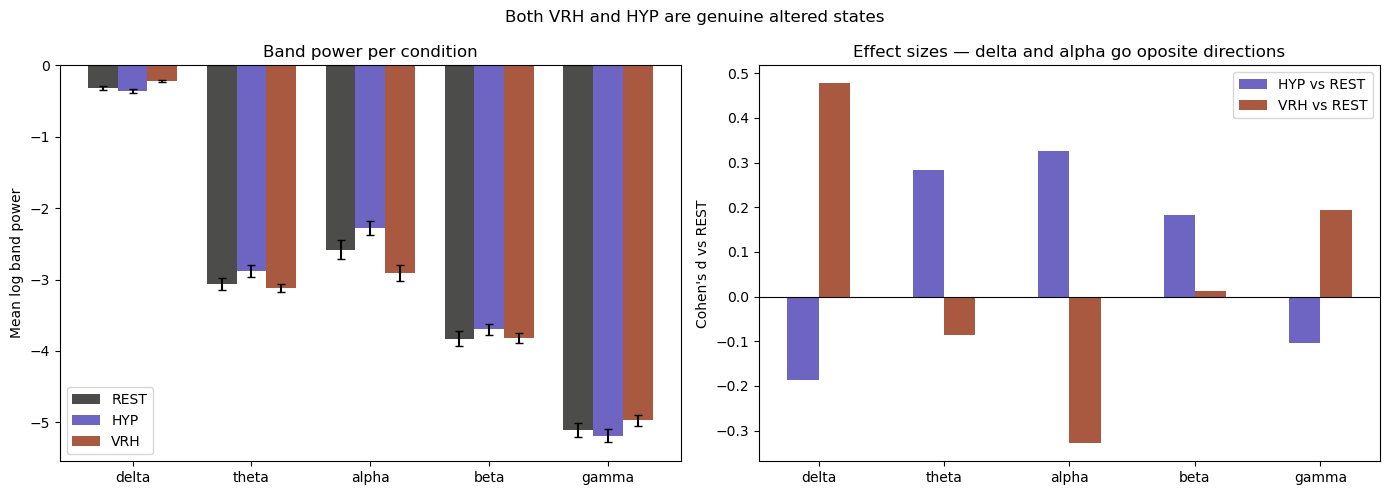

In [3]:
# Statistical Validation

def cohens_d(a, b):
    """
    Independent-samples pooled Cohen's d.
    Slightly conservative for paired data.
    For publication: use paired d = mean(diff)/std(diff).
    d=0.2 small, d=0.5 medium, d=0.8 large.
    """
    n1, n2 = len(a), len(b)
    pooled = np.sqrt(((n1-1)*a.var(ddof=1) +
                      (n2-1)*b.var(ddof=1)) / (n1+n2-2))
    return (a.mean() - b.mean()) / (pooled + 1e-8)


log_bp = np.log(all_bpower + 1e-8)

def paired_table(idx_a, idx_b, label_a, label_b):
    """Print paired t-test results for all 5 bands."""
    print(f'\nPaired t-test: {label_b} vs {label_a}')
    print(f'{"Band":8s}  {label_a:>10}  {label_b:>10}  '
          f'{"t":>7}  {"p":>8}  {"d":>8}')
    print('-' * 58)
    for b, band in enumerate(BAND_NAMES):
        a_v = log_bp[y==idx_a, b, :].mean(axis=1)
        b_v = log_bp[y==idx_b, b, :].mean(axis=1)
        t, p = stats.ttest_rel(b_v, a_v)
        d    = cohens_d(b_v, a_v)
        sig  = '*' if p < 0.05 else ('~' if p < 0.10 else '')
        print(f'{band:8s}  {a_v.mean():>10.3f}  '
              f'{b_v.mean():>10.3f}  '
              f'{t:>7.3f}  {p:>8.4f}  '
              f'{d:>8.4f}  {sig}')

paired_table(0, 2, 'REST', 'VRH')
paired_table(0, 1, 'REST', 'HYP')
paired_table(1, 2, 'HYP',  'VRH')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means = {c: log_bp[y==i].mean(axis=(0, 2))
         for i, c in enumerate(CONDITIONS)}
sems  = {c: log_bp[y==i].mean(axis=2).std(axis=0)
            / np.sqrt((y==i).sum())
         for i, c in enumerate(CONDITIONS)}

x, w = np.arange(N_BANDS), 0.25
for i, (cond, col) in enumerate(
        zip(CONDITIONS, [C_REST, C_HYP, C_VRH])):
    axes[0].bar(x + (i-1)*w, means[cond], w,
                yerr=sems[cond], capsize=3,
                label=cond, color=col, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(BAND_NAMES)
axes[0].set_ylabel('Mean log band power')
axes[0].set_title('Band power per condition')
axes[0].legend()

d_hyp = [cohens_d(log_bp[y==1, b, :].mean(axis=1),
                   log_bp[y==0, b, :].mean(axis=1))
         for b in range(N_BANDS)]
d_vrh = [cohens_d(log_bp[y==2, b, :].mean(axis=1),
                   log_bp[y==0, b, :].mean(axis=1))
         for b in range(N_BANDS)]

axes[1].bar(x - w/2, d_hyp, w,
            label='HYP vs REST',
            color=C_HYP, alpha=0.85)
axes[1].bar(x + w/2, d_vrh, w,
            label='VRH vs REST',
            color=C_VRH, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(BAND_NAMES)
axes[1].set_ylabel("Cohen's d vs REST")
axes[1].set_title(
    'Effect sizes — delta and alpha go oposite directions')
axes[1].legend()

plt.suptitle(
    'Both VRH and HYP are genuine altered states',
    fontsize=12)
plt.tight_layout()
plt.savefig('fig_statistical_validation.png', dpi=150)
plt.show()

In [4]:
#  Feature Engineering
# Feature set:  Power, connectivity, pow + conn
triu_idx  = np.triu_indices(N_CH, k=1)
TOKEN_DIM = N_CH + len(triu_idx[0])  # 127 + 8001 = 8128

def build_tokens(bpower, dwpli):
    """
    Build 5 band tokens for one recording.

    For each band b:
      - bpower[b] shape (127,): log power across channels
      - dwpli[b][triu_idx] shape (8001,): upper triangle
      - concatenate : shape (8128,)
    Stack 5 bands : shape (5, 8128)
    """
    tokens = []
    for b in range(N_BANDS):
        power_b = np.log(bpower[b] + 1e-8)
        conn_b  = dwpli[b][triu_idx
        ]
        tokens.append(np.concatenate([power_b, conn_b]))
    return np.stack(tokens)  # (5, 8128)

X_all_full = np.array([
    build_tokens(all_bpower[i], all_dwpli[i])
    for i in range(len(y))
], dtype=np.float32)

# REST is removed because the task is HYP vs VRH
mask     = (y == 1) | (y == 2)
X_both   = X_all_full[mask]
# binary label: 0=HYP, 1=VRH
y_bin    = (y[mask] == 2).astype(np.int64)
subjects = all_subjects[mask]

# power only, positions 0:127 = power, 127:8128 = connectivity
X_power            = X_both.copy()
X_power[:, :, N_CH:] = 0

# connectivity only
X_conn             = X_both.copy()
X_conn[:, :, :N_CH] = 0

print(f'Samples      : {len(y_bin)} '
      f'(HYP={(y_bin==0).sum()}  '
      f'VRH={(y_bin==1).sum()})')
print(f'Subjects     : {len(np.unique(subjects))}')
print(f'Token dim    : {TOKEN_DIM}')
print(f'X_both shape : {X_both.shape}')

feature_sets = {
    'Power only':   X_power,
    'Conn only':    X_conn,
    'Power + Conn': X_both,
}

Samples      : 132 (HYP=66  VRH=66)
Subjects     : 66
Token dim    : 8128
X_both shape : (132, 5, 8128)


In [5]:
def bootstrap_ci(fold_accs, n_boot=2000, ci=95):
    """
    Non-parametric bootstrap CI around mean LOSO accuracy.

    Resamples the 66 fold accuracy values (each 0, 0.5, or 1)
    with replacement 2000 times. Takes percentiles of the
    bootstrap distribution as confidence bounds.

    Makes no distributional assumptions — appropriate
    because LOSO fold accuracies are not normally distributed.
    """
    # convert to numpy to have mean() 
    fold_accs  = np.array(fold_accs)
    boot_means = [
        resample(fold_accs, replace=True,
                 random_state=i).mean()
        for i in range(n_boot)
    ]
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return fold_accs.mean(), lo, hi


def pca_per_band(X_train_raw, X_test_raw, n_comp=N_COMP):
    """
    PCA compression per frequency band.

    fitted on training set only.
    Applying PCA fitted on all data before splitting
    would leak test information into training. The
    model would indirectly know something about the
    test subject during training. Fitting inside the
    fold prevents this.

    Returns X_train and X_test both shape (n, N_BANDS, n_comp)
    """
    n_bands = X_train_raw.shape[1]
    X_train = np.zeros(
        (len(X_train_raw), n_bands, n_comp),
        dtype=np.float32)
    X_test  = np.zeros(
        (len(X_test_raw), n_bands, n_comp),
        dtype=np.float32)

    for b in range(n_bands):
        band_train = X_train_raw[:, b, :]
        if np.allclose(band_train, 0):
            continue
        sc  = StandardScaler()
        pca = PCA(n_components=n_comp, random_state=SEED)
        ts  = sc.fit_transform(band_train)
        if np.isnan(ts).any() or np.allclose(ts, 0):
            continue
        X_train[:, b, :] = pca.fit_transform(ts)
        X_test[:, b, :]  = pca.transform(
            sc.transform(X_test_raw[:, b, :]))

    return X_train, X_test


def print_metrics(label, mean_acc, fold_accs,
                  all_preds, all_true):
    """Print accuracy, precision, recall, F1, CI, p-value."""
    _, lo, hi = bootstrap_ci(fold_accs)
    bt = binomtest(
        int(round(mean_acc * len(all_true))),
        len(all_true), p=0.5,
        alternative='greater')
    sig = ('*' if bt.pvalue < 0.05 else
           '~' if bt.pvalue < 0.10 else 'n.s.')

    prec, rec, f1, _ = precision_recall_fscore_support(
        all_true, all_preds,
        average='macro', zero_division=0)

    print(f'\n  -- {label} --')
    print(f'  Accuracy  : {mean_acc:.3f}  '
          f'(95% CI: [{lo:.3f} - {hi:.3f}])')
    print(f'  Precision : {prec:.3f}')
    print(f'  Recall    : {rec:.3f}')
    print(f'  F1-score  : {f1:.3f}')
    print(f'  p-value   : {bt.pvalue:.4f}  {sig}')
    print(f'  Chance    : 0.500')

    return lo, hi, bt.pvalue



In [6]:
# SVM (RBF kernel)

def loso_svm(X_input, y_input, subj_input,
             n_comp=N_COMP, C=1.0, label=''):
    fold_accs, all_preds, all_true, all_proba = \
        [], [], [], []

    for fold, test_subj in enumerate(
            np.unique(subj_input)):

        tr = subj_input != test_subj
        te = subj_input == test_subj

        # PCA inside fold to prevents data leakage
        X_tr, X_te = pca_per_band(
            X_input[tr], X_input[te], n_comp)

        
        X_tr_f = X_tr.reshape(len(X_tr), -1)
        X_te_f = X_te.reshape(len(X_te), -1)

        
        sc     = StandardScaler()
        X_tr_f = sc.fit_transform(X_tr_f)
        X_te_f = sc.transform(X_te_f)

        clf = SVC(kernel='rbf', C=C,
                  probability=False,  
                  random_state=SEED)
        clf.fit(X_tr_f, y_input[tr])
        preds = clf.predict(X_te_f)

      
        proba = clf.decision_function(X_te_f)

        fold_accs.append((preds == y_input[te]).mean())
        all_preds.append(preds)
        all_true.append(y_input[te])
        all_proba.append(proba)

        if (fold + 1) % 10 == 0 or fold == 0:
            print(f'  fold {fold+1:2d}/66  '
                  f'mean: {np.mean(fold_accs):.3f}')

    all_preds = np.concatenate(all_preds)
    all_true  = np.concatenate(all_true)
    all_proba = np.concatenate(all_proba)
    mean_acc  = np.mean(fold_accs)

    if label:
        print_metrics(label, mean_acc,
                      fold_accs, all_preds, all_true)

    return mean_acc, fold_accs, all_preds, \
           all_true, all_proba


svm_results = {}
for feat_name, X_feat in feature_sets.items():
    print(f'\n{"-"*50}')
    print(f'SVM - {feat_name}')
    acc, fa, preds, true, proba = loso_svm(
        X_feat, y_bin, subjects,
        label=f'SVM ({feat_name})')
    svm_results[feat_name] = dict(
        acc=acc, fold_accs=fa,
        preds=preds, true=true, proba=proba)



--------------------------------------------------
SVM - Power only
  fold  1/66  mean: 0.500
  fold 10/66  mean: 0.800
  fold 20/66  mean: 0.700
  fold 30/66  mean: 0.700
  fold 40/66  mean: 0.675
  fold 50/66  mean: 0.690
  fold 60/66  mean: 0.700

  -- SVM (Power only) --
  Accuracy  : 0.705  (95% CI: [0.644 - 0.773])
  Precision : 0.705
  Recall    : 0.705
  F1-score  : 0.704
  p-value   : 0.0000  *
  Chance    : 0.500

--------------------------------------------------
SVM - Conn only
  fold  1/66  mean: 0.500
  fold 10/66  mean: 0.500
  fold 20/66  mean: 0.550
  fold 30/66  mean: 0.550
  fold 40/66  mean: 0.550
  fold 50/66  mean: 0.570
  fold 60/66  mean: 0.550

  -- SVM (Conn only) --
  Accuracy  : 0.553  (95% CI: [0.500 - 0.614])
  Precision : 0.577
  Recall    : 0.553
  F1-score  : 0.515
  p-value   : 0.1289  n.s.
  Chance    : 0.500

--------------------------------------------------
SVM - Power + Conn
  fold  1/66  mean: 0.500
  fold 10/66  mean: 0.600
  fold 20/66  mean: 

In [7]:
# LDA (Regularised)

def loso_lda(X_input, y_input, subj_input,
             n_comp=N_COMP, label=''):
    fold_accs, all_preds, all_true, all_proba = \
        [], [], [], []

    for fold, test_subj in enumerate(
            np.unique(subj_input)):

        tr = subj_input != test_subj
        te = subj_input == test_subj

        X_tr, X_te = pca_per_band(
            X_input[tr], X_input[te], n_comp)

        X_tr_f = X_tr.reshape(len(X_tr), -1).astype(np.float32)
        X_te_f = X_te.reshape(len(X_te), -1).astype(np.float32)

        sc     = StandardScaler()
        X_tr_f = sc.fit_transform(X_tr_f)
        X_te_f = sc.transform(X_te_f)

        clf = LinearDiscriminantAnalysis(
            solver='eigen',
            shrinkage='auto')  
        clf.fit(X_tr_f, y_input[tr])
        preds = clf.predict(X_te_f)
        proba = clf.decision_function(X_te_f)

        fold_accs.append((preds == y_input[te]).mean())
        all_preds.append(preds)
        all_true.append(y_input[te])
        all_proba.append(proba)

        if (fold + 1) % 10 == 0 or fold == 0:
            print(f'  fold {fold+1:2d}/66  '
                  f'mean: {np.mean(fold_accs):.3f}')

    all_preds = np.concatenate(all_preds)
    all_true  = np.concatenate(all_true)
    all_proba = np.concatenate(all_proba)
    mean_acc  = np.mean(fold_accs)

    if label:
        print_metrics(label, mean_acc,
                      fold_accs, all_preds, all_true)

    return mean_acc, fold_accs, all_preds, \
           all_true, all_proba


lda_results = {}
for feat_name, X_feat in feature_sets.items():
    print(f'\n{"-"*50}')
    print(f'LDA - {feat_name}')
    acc, fa, preds, true, proba = loso_lda(
        X_feat, y_bin, subjects,
        label=f'LDA ({feat_name})')
    lda_results[feat_name] = dict(
        acc=acc, fold_accs=fa,
        preds=preds, true=true, proba=proba)




--------------------------------------------------
LDA - Power only
  fold  1/66  mean: 0.500
  fold 10/66  mean: 0.750
  fold 20/66  mean: 0.700
  fold 30/66  mean: 0.683
  fold 40/66  mean: 0.662
  fold 50/66  mean: 0.670
  fold 60/66  mean: 0.683

  -- LDA (Power only) --
  Accuracy  : 0.682  (95% CI: [0.621 - 0.743])
  Precision : 0.682
  Recall    : 0.682
  F1-score  : 0.682
  p-value   : 0.0000  *
  Chance    : 0.500

--------------------------------------------------
LDA - Conn only
  fold  1/66  mean: 0.500
  fold 10/66  mean: 0.600
  fold 20/66  mean: 0.625
  fold 30/66  mean: 0.583
  fold 40/66  mean: 0.562
  fold 50/66  mean: 0.580
  fold 60/66  mean: 0.567

  -- LDA (Conn only) --
  Accuracy  : 0.568  (95% CI: [0.492 - 0.644])
  Precision : 0.569
  Recall    : 0.568
  F1-score  : 0.567
  p-value   : 0.0693  ~
  Chance    : 0.500

--------------------------------------------------
LDA - Power + Conn
  fold  1/66  mean: 0.500
  fold 10/66  mean: 0.600
  fold 20/66  mean: 0.5

In [8]:
#  Random Forest; 200 decision trees
def loso_rf(X_input, y_input, subj_input,
            n_comp=N_COMP, n_estimators=200,
            label=''):
    fold_accs, all_preds, all_true, all_proba = \
        [], [], [], []

    for fold, test_subj in enumerate(
            np.unique(subj_input)):

        tr = subj_input != test_subj
        te = subj_input == test_subj

        X_tr, X_te = pca_per_band(
            X_input[tr], X_input[te], n_comp)

        X_tr_f = X_tr.reshape(len(X_tr), -1)
        X_te_f = X_te.reshape(len(X_te), -1)

        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            random_state=SEED, n_jobs=-1)
        clf.fit(X_tr_f, y_input[tr])
        preds = clf.predict(X_te_f)
        proba = clf.predict_proba(X_te_f)[:, 1]

        fold_accs.append((preds == y_input[te]).mean())
        all_preds.append(preds)
        all_true.append(y_input[te])
        all_proba.append(proba)

        if (fold + 1) % 10 == 0 or fold == 0:
            print(f'  fold {fold+1:2d}/66  '
                  f'mean: {np.mean(fold_accs):.3f}')

    all_preds = np.concatenate(all_preds)
    all_true  = np.concatenate(all_true)
    all_proba = np.concatenate(all_proba)
    mean_acc  = np.mean(fold_accs)

    if label:
        print_metrics(label, mean_acc,
                      fold_accs, all_preds, all_true)

    return mean_acc, fold_accs, all_preds, \
           all_true, all_proba


rf_results = {}
for feat_name, X_feat in feature_sets.items():
    print(f'\n{"-"*50}')
    print(f'Random Forest - {feat_name}')
    acc, fa, preds, true, proba = loso_rf(
        X_feat, y_bin, subjects,
        label=f'Random Forest ({feat_name})')
    rf_results[feat_name] = dict(
        acc=acc, fold_accs=fa,
        preds=preds, true=true, proba=proba)



--------------------------------------------------
Random Forest - Power only
  fold  1/66  mean: 0.500
  fold 10/66  mean: 0.800
  fold 20/66  mean: 0.725
  fold 30/66  mean: 0.733
  fold 40/66  mean: 0.688
  fold 50/66  mean: 0.680
  fold 60/66  mean: 0.650

  -- Random Forest (Power only) --
  Accuracy  : 0.629  (95% CI: [0.568 - 0.689])
  Precision : 0.629
  Recall    : 0.629
  F1-score  : 0.629
  p-value   : 0.0020  *
  Chance    : 0.500

--------------------------------------------------
Random Forest - Conn only
  fold  1/66  mean: 0.500
  fold 10/66  mean: 0.450
  fold 20/66  mean: 0.525
  fold 30/66  mean: 0.550
  fold 40/66  mean: 0.562
  fold 50/66  mean: 0.560
  fold 60/66  mean: 0.558

  -- Random Forest (Conn only) --
  Accuracy  : 0.561  (95% CI: [0.485 - 0.636])
  Precision : 0.561
  Recall    : 0.561
  F1-score  : 0.560
  p-value   : 0.0957  ~
  Chance    : 0.500

--------------------------------------------------
Random Forest - Power + Conn
  fold  1/66  mean: 0.500

In [9]:
# XGBoost

def loso_xgb(X_input, y_input, subj_input,
             n_comp=N_COMP, label=''):
    fold_accs, all_preds, all_true, all_proba = \
        [], [], [], []

    for fold, test_subj in enumerate(
            np.unique(subj_input)):

        tr = subj_input != test_subj
        te = subj_input == test_subj

        X_tr, X_te = pca_per_band(
            X_input[tr], X_input[te], n_comp)

        X_tr_f = X_tr.reshape(len(X_tr), -1)
        X_te_f = X_te.reshape(len(X_te), -1)

        clf = XGBClassifier(
            n_estimators=100, max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=SEED, verbosity=0)
        clf.fit(X_tr_f, y_input[tr])
        preds = clf.predict(X_te_f)
        proba = clf.predict_proba(X_te_f)[:, 1]

        fold_accs.append((preds == y_input[te]).mean())
        all_preds.append(preds)
        all_true.append(y_input[te])
        all_proba.append(proba)

        if (fold + 1) % 10 == 0 or fold == 0:
            print(f'  fold {fold+1:2d}/66  '
                  f'mean: {np.mean(fold_accs):.3f}')

    all_preds = np.concatenate(all_preds)
    all_true  = np.concatenate(all_true)
    all_proba = np.concatenate(all_proba)
    mean_acc  = np.mean(fold_accs)

    if label:
        print_metrics(label, mean_acc,
                      fold_accs, all_preds, all_true)

    return mean_acc, fold_accs, all_preds, \
           all_true, all_proba


xgb_results = {}
for feat_name, X_feat in feature_sets.items():
    print(f'\n{"-"*50}')
    print(f'XGBoost — {feat_name}')
    acc, fa, preds, true, proba = loso_xgb(
        X_feat, y_bin, subjects,
        label=f'XGBoost ({feat_name})')
    xgb_results[feat_name] = dict(
        acc=acc, fold_accs=fa,
        preds=preds, true=true, proba=proba)



--------------------------------------------------
XGBoost — Power only
  fold  1/66  mean: 0.000
  fold 10/66  mean: 0.800
  fold 20/66  mean: 0.725
  fold 30/66  mean: 0.717
  fold 40/66  mean: 0.675
  fold 50/66  mean: 0.680
  fold 60/66  mean: 0.675

  -- XGBoost (Power only) --
  Accuracy  : 0.674  (95% CI: [0.598 - 0.750])
  Precision : 0.674
  Recall    : 0.674
  F1-score  : 0.674
  p-value   : 0.0000  *
  Chance    : 0.500

--------------------------------------------------
XGBoost — Conn only
  fold  1/66  mean: 0.500
  fold 10/66  mean: 0.500
  fold 20/66  mean: 0.525
  fold 30/66  mean: 0.550
  fold 40/66  mean: 0.588
  fold 50/66  mean: 0.580
  fold 60/66  mean: 0.550

  -- XGBoost (Conn only) --
  Accuracy  : 0.561  (95% CI: [0.492 - 0.629])
  Precision : 0.562
  Recall    : 0.561
  F1-score  : 0.558
  p-value   : 0.0957  ~
  Chance    : 0.500

--------------------------------------------------
XGBoost — Power + Conn
  fold  1/66  mean: 0.500
  fold 10/66  mean: 0.500
  f

In [10]:
# Logistic Regression (L2 Regularised)

from sklearn.linear_model import LogisticRegression

def loso_lr(X_input, y_input, subj_input,
            n_comp=N_COMP, C=1.0, label=''):
    """
    LOSO-CV for L2-regularised Logistic Regression.

    Parameters
    ----------
    X_input    : (N, N_BANDS, TOKEN_DIM) feature array
    y_input    : (N,) binary labels 0=HYP 1=VRH
    subj_input : (N,) subject IDs for LOSO splits
    n_comp     : PCA components per band (default 50)
    C          : inverse regularisation strength (default 1.0)
                 smaller C = stronger regularisation
    label      : string for printing

    Returns
    -------
    mean_acc, fold_accs, all_preds, all_true, all_proba
    """
    fold_accs, all_preds, all_true, all_proba = \
        [], [], [], []

    unique_subjects = np.unique(subj_input)

    for fold, test_subj in enumerate(unique_subjects):

        # -- split ------------------------------------------
        tr = subj_input != test_subj
        te = subj_input == test_subj

        y_tr = y_input[tr]
        y_te = y_input[te]

       
        X_tr, X_te = pca_per_band(
            X_input[tr], X_input[te], n_comp)

     
        X_tr_f = X_tr.reshape(
            len(y_tr), -1).astype(np.float32)
        X_te_f = X_te.reshape(
            len(y_te), -1).astype(np.float32)

       
        sc     = StandardScaler()
        X_tr_f = sc.fit_transform(X_tr_f)
        X_te_f = sc.transform(X_te_f)

       
        clf = LogisticRegression(
            C=C,                    # inverse regularisation
            penalty='l2',           # L2 = weight decay
            solver='lbfgs',         # efficient for small data
            max_iter=1000,          # ensure convergence
            random_state=SEED)

        clf.fit(X_tr_f, y_tr)
        preds = clf.predict(X_te_f)

        
        proba = clf.predict_proba(X_te_f)[:, 1]

        fold_accs.append((preds == y_te).mean())
        all_preds.append(preds)
        all_true.append(y_te)
        all_proba.append(proba)

        if (fold + 1) % 10 == 0 or fold == 0:
            print(f'  fold {fold+1:2d}/66  '
                  f'running mean: '
                  f'{np.mean(fold_accs):.3f}')

    all_preds = np.concatenate(all_preds)
    all_true  = np.concatenate(all_true)
    all_proba = np.concatenate(all_proba)
    mean_acc  = np.mean(fold_accs)

    bt = binomtest(
        int(round(mean_acc * len(all_true))),
        len(all_true), p=0.5,
        alternative='greater')
    _, lo, hi = bootstrap_ci(fold_accs)
    sig = ('*' if bt.pvalue < 0.05 else
           '~' if bt.pvalue < 0.10 else 'n.s.')

    if label:
        print_metrics(label, mean_acc,
                      fold_accs, all_preds, all_true)

    return mean_acc, fold_accs, all_preds, \
           all_true, all_proba


feature_sets = {
    'Power only':   X_power,
    'Conn only':    X_conn,
    'Power + Conn': X_both,
}

lr_results = {}

for feat_name, X_feat in feature_sets.items():
    print(f'\n{"-"*50}')
    print(f'Logistic Regression — {feat_name}')
    print(f'{"-"*50}')

    acc, fa, preds, true, proba = loso_lr(
        X_feat, y_bin, subjects,
        n_comp=N_COMP, C=1.0,
        label=f'Logistic Regression ({feat_name})')

    lr_results[feat_name] = dict(
        acc=acc, fold_accs=fa,
        preds=preds, true=true,
        proba=proba)

print(f'\n{"="*58}')
print(f'LOGISTIC REGRESSION RESULTS SUMMARY')
print(f'{"="*58}')
print(f'{"Feature Set":16s}  {"Acc":>6}  '
      f'{"95% CI":>18}  {"p":>8}  {"Sig":>6}')
print('-' * 58)

for feat_name, res in lr_results.items():
    mean_acc = res['acc']
    _, lo, hi = bootstrap_ci(res['fold_accs'])
    bt = binomtest(
        int(round(mean_acc * len(res['true']))),
        len(res['true']), 0.5,
        alternative='greater')
    sig = ('*' if bt.pvalue < 0.05 else
           '~' if bt.pvalue < 0.10 else 'n.s.')
    print(f'{feat_name:16s}  {mean_acc:.3f}  '
          f'[{lo:.3f} - {hi:.3f}]  '
          f'{bt.pvalue:.4f}  {sig:>6}')

print('-' * 58)
print(f'{"Chance":16s}  {"0.500":>6}')
print(f'{"="*58}')


--------------------------------------------------
Logistic Regression — Power only
--------------------------------------------------
  fold  1/66  running mean: 0.500
  fold 10/66  running mean: 0.700
  fold 20/66  running mean: 0.650
  fold 30/66  running mean: 0.650
  fold 40/66  running mean: 0.625
  fold 50/66  running mean: 0.630
  fold 60/66  running mean: 0.633

  -- Logistic Regression (Power only) --
  Accuracy  : 0.636  (95% CI: [0.568 - 0.705])
  Precision : 0.638
  Recall    : 0.636
  F1-score  : 0.635
  p-value   : 0.0011  *
  Chance    : 0.500

--------------------------------------------------
Logistic Regression — Conn only
--------------------------------------------------
  fold  1/66  running mean: 0.500
  fold 10/66  running mean: 0.600
  fold 20/66  running mean: 0.650
  fold 30/66  running mean: 0.600
  fold 40/66  running mean: 0.588
  fold 50/66  running mean: 0.600
  fold 60/66  running mean: 0.592

  -- Logistic Regression (Conn only) --
  Accuracy  : 0.591

In [11]:
# Regression Inference

from scipy.stats import f_oneway
import numpy.linalg as la

def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled = np.sqrt(((n1-1)*a.var(ddof=1) +
                      (n2-1)*b.var(ddof=1)) / (n1+n2-2))
    return (a.mean() - b.mean()) / (pooled + 1e-8)

all_ml_results = {
    'SVM':      svm_results,
    'LDA':      lda_results,
    'Log Reg':  lr_results,
    'Rand Forest': rf_results,
    'XGBoost':  xgb_results,
}
model_order_ml = list(all_ml_results.keys())
feat_order     = ['Power only', 'Conn only', 'Power + Conn']

# -- group by feature type -------------------------------------
power_accs = np.array([
    all_ml_results[m]['Power only']['acc']
    for m in model_order_ml])
conn_accs  = np.array([
    all_ml_results[m]['Conn only']['acc']
    for m in model_order_ml])
both_accs  = np.array([
    all_ml_results[m]['Power + Conn']['acc']
    for m in model_order_ml])

print(f'Mean accuracy by feature type:')
print(f'  Power only   : {power_accs.mean():.3f} '
      f'± {power_accs.std():.3f}')
print(f'  Conn only    : {conn_accs.mean():.3f} '
      f'± {conn_accs.std():.3f}')
print(f'  Power + Conn : {both_accs.mean():.3f} '
      f'± {both_accs.std():.3f}')

# ANOVA 
F, p_anova = f_oneway(power_accs, conn_accs, both_accs)
print(f'\nOne-way ANOVA: F={F:.3f}  p={p_anova:.4f} '
      f'{"*" if p_anova<0.05 else "n.s."}')

# pairwise paired t-tests 
t_pc, p_pc = stats.ttest_rel(power_accs, conn_accs)
d_pc = cohens_d(power_accs, conn_accs)

t_pb, p_pb = stats.ttest_rel(power_accs, both_accs)
d_pb = cohens_d(power_accs, both_accs)

t_cb, p_cb = stats.ttest_rel(conn_accs, both_accs)
d_cb = cohens_d(conn_accs, both_accs)

print(f'\nPairwise comparisons:')
print(f'  Power vs Conn  : '
      f't={t_pc:.3f} p={p_pc:.4f} d={d_pc:.3f} '
      f'{"*" if p_pc<0.05 else "n.s."}')
print(f'  Power vs Both  : '
      f't={t_pb:.3f} p={p_pb:.4f} d={d_pb:.3f} '
      f'{"*" if p_pb<0.05 else "n.s."}')
print(f'  Conn vs Both   : '
      f't={t_cb:.3f} p={p_cb:.4f} d={d_cb:.3f} '
      f'{"*" if p_cb<0.05 else "n.s."}')

# -- linear regression -----------------------------------------
rows = []
for m in model_order_ml:
    for f in feat_order:
        rows.append({
            'accuracy': all_ml_results[m][f]['acc'],
            'is_power': float(f == 'Power only'),
            'is_conn':  float(f == 'Conn only'),
        })
df_reg = pd.DataFrame(rows)

from sklearn.linear_model import LinearRegression

X_reg = df_reg[['is_power', 'is_conn']].values
y_reg = df_reg['accuracy'].values
reg   = LinearRegression().fit(X_reg, y_reg)

n, k   = len(y_reg), X_reg.shape[1]
resid  = y_reg - reg.predict(X_reg)
mse    = (resid**2).sum() / (n - k - 1)
X_aug  = np.column_stack([np.ones(n), X_reg])
cov    = mse * la.inv(X_aug.T @ X_aug)
se     = np.sqrt(np.diag(cov))
coefs  = np.array([reg.intercept_, *reg.coef_])
t_vals = coefs / se
p_vals = 2 * (1 - stats.t.cdf(
    np.abs(t_vals), df=n-k-1))
r2     = reg.score(X_reg, y_reg)

print(f'\nLinear regression '
      f'(reference = Power+Conn):')
print(f'  {"Term":20s}  {"β":>8}  '
      f'{"p":>8}  {"Sig":>6}')
print('  ' + '-'*45)
for term, b, p in zip(
        ['Intercept (P+C)', 'Power only', 'Conn only'],
        coefs, p_vals):
    sig = ('*' if p < 0.05 else
           '~' if p < 0.10 else 'n.s.')
    print(f'  {term:20s}  {b:+8.4f}  '
          f'{p:8.4f}  {sig:>6}')

print(f'\n  R² = {r2:.3f} — feature type explains '
      f'{r2*100:.1f}% of accuracy variance')

# store for figures
reg_coefs  = coefs
reg_p_vals = p_vals
reg_r2     = r2
reg_F      = F
reg_p_anova = p_anova



Mean accuracy by feature type:
  Power only   : 0.665 ± 0.029
  Conn only    : 0.567 ± 0.013
  Power + Conn : 0.598 ± 0.028

One-way ANOVA: F=16.972  p=0.0003 *

Pairwise comparisons:
  Power vs Conn  : t=5.264 p=0.0062 d=3.974 *
  Power vs Both  : t=3.184 p=0.0334 d=2.098 *
  Conn vs Both   : t=-2.585 p=0.0610 d=-1.290 n.s.

Linear regression (reference = Power+Conn):
  Term                         β         p     Sig
  ---------------------------------------------
  Intercept (P+C)        +0.5985    0.0000       *
  Power only             +0.0667    0.0023       *
  Conn only              -0.0318    0.0900       ~

  R² = 0.739 — feature type explains 73.9% of accuracy variance


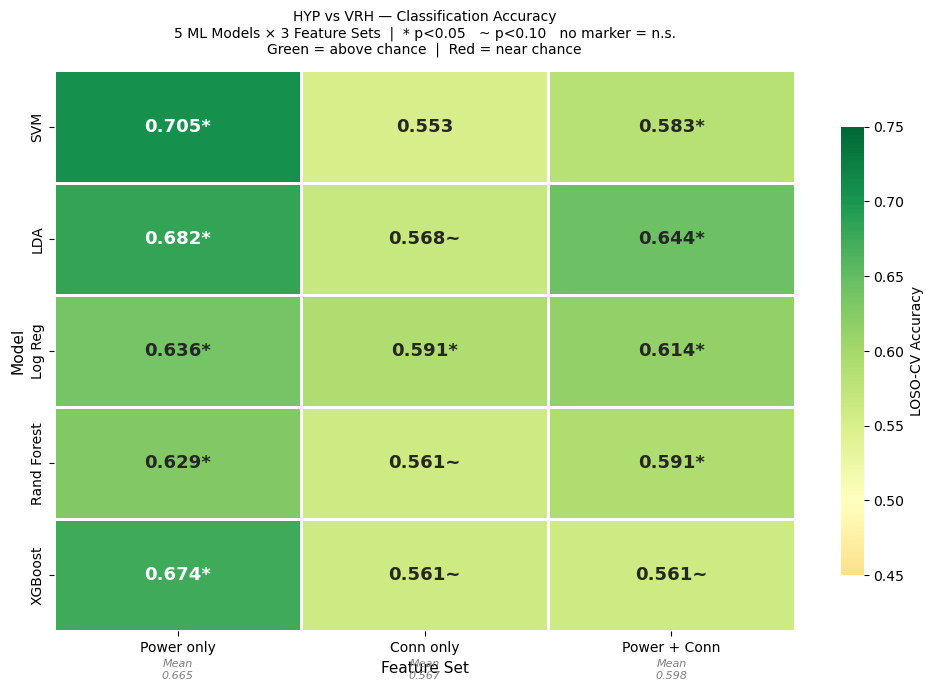

Figure 1 — Heatmap saved 


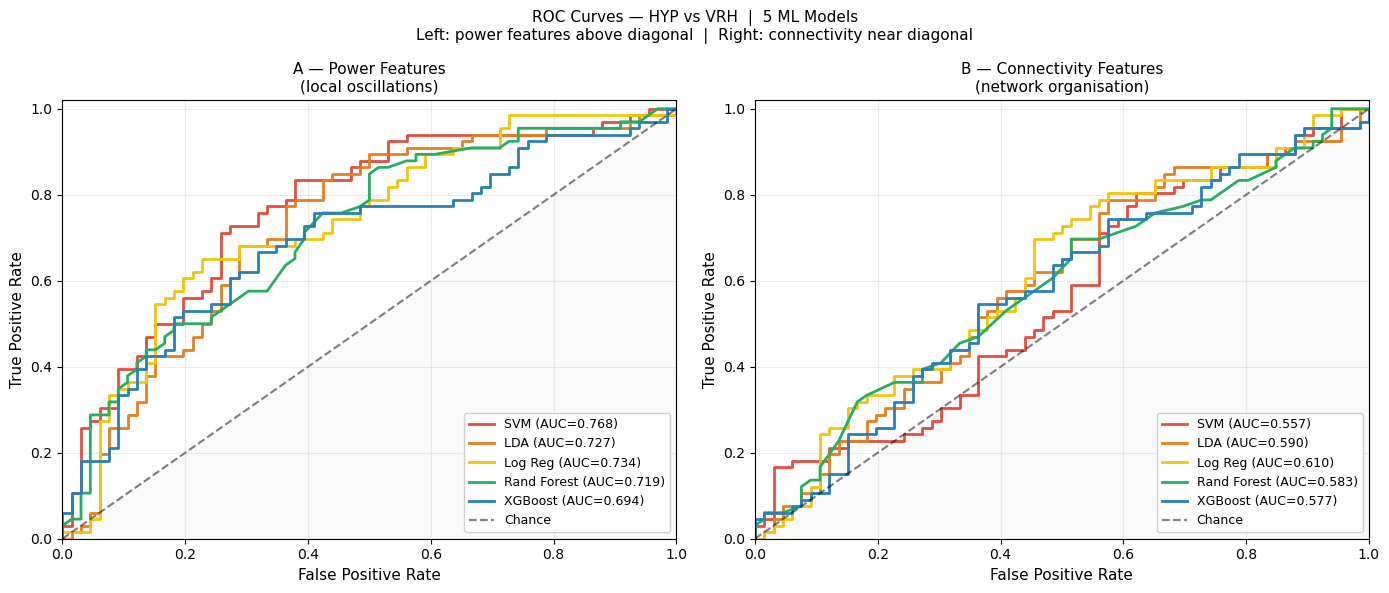

Figure 2 — ROC curves saved 


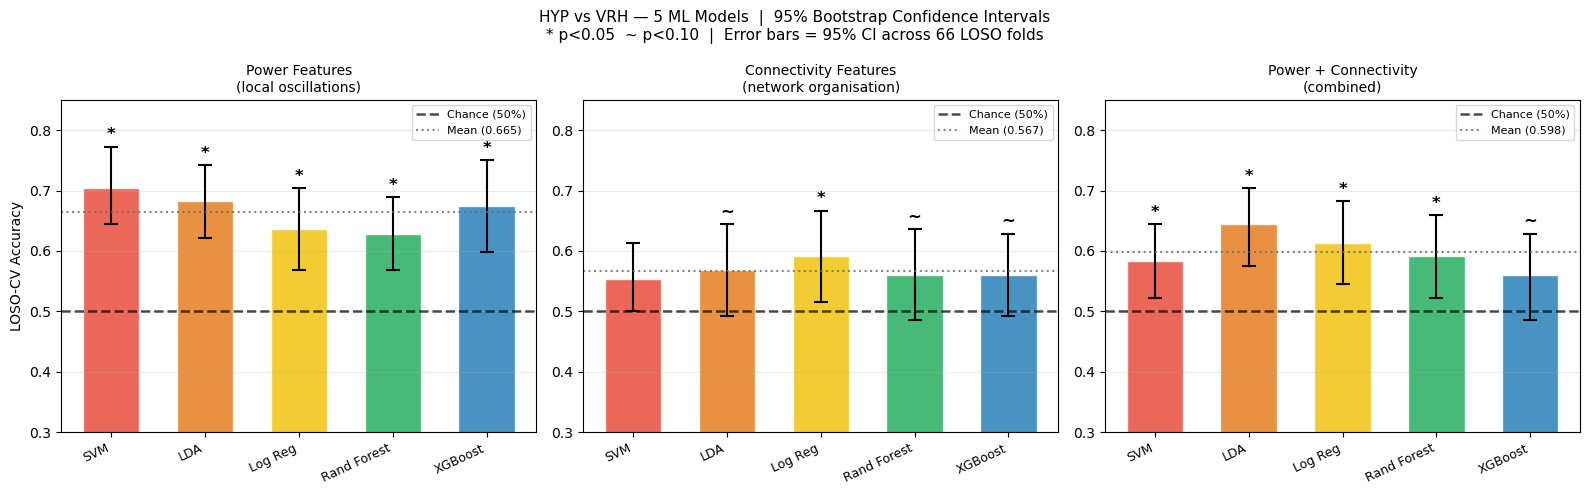

Figure 3 — Bootstrap CI saved 


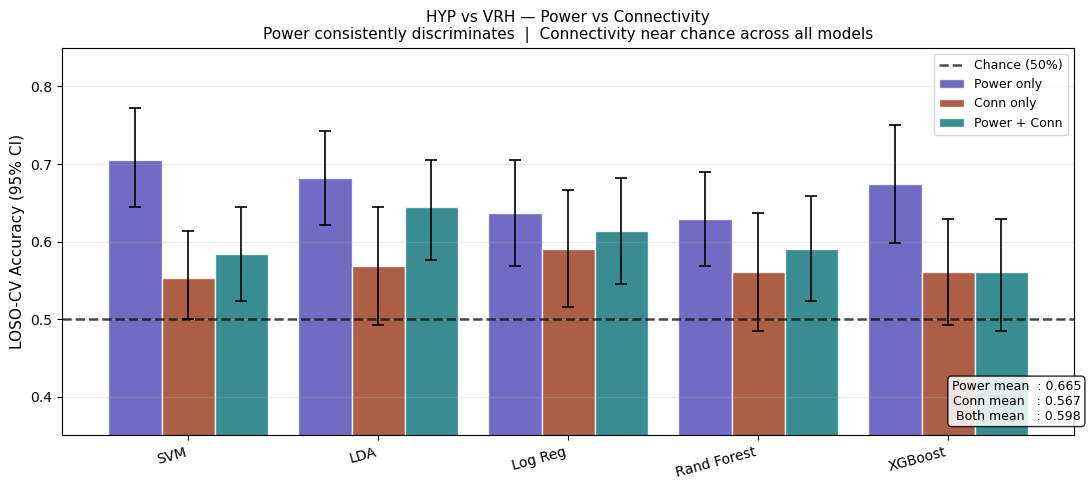

Figure 4 — Power vs Connectivity saved 


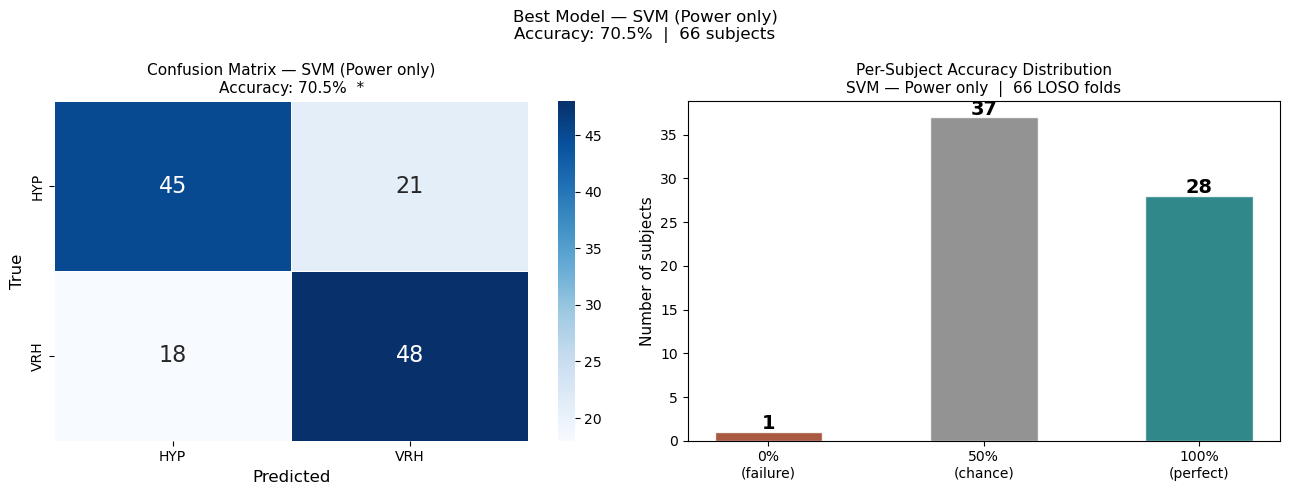

Figure 5 — Confusion matrix saved 


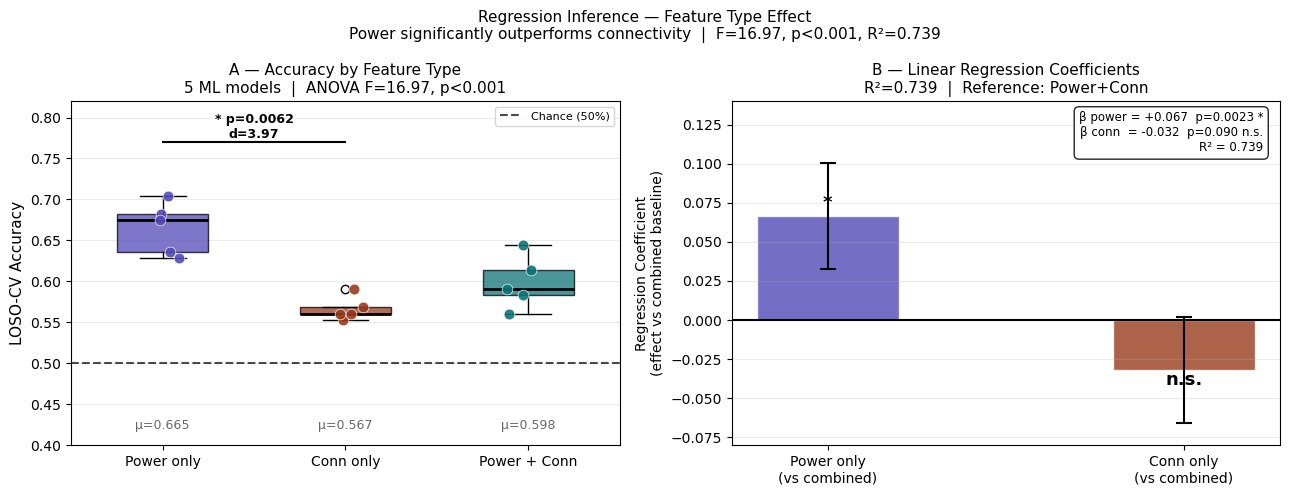

Figure 6 — Regression inference saved 

All ML figures saved:
  fig_ml_heatmap.png
  fig_ml_roc.png
  fig_ml_bootstrap_ci.png
  fig_ml_power_vs_conn.png
  fig_ml_confusion.png
  fig_ml_regression.png


In [12]:
#  ML Visualisations

n_models = len(model_order_ml)
n_feats  = len(feat_order)

acc_matrix = np.zeros((n_models, n_feats))
p_matrix   = np.zeros((n_models, n_feats))
lo_matrix  = np.zeros((n_models, n_feats))
hi_matrix  = np.zeros((n_models, n_feats))

for i, m in enumerate(model_order_ml):
    for j, f in enumerate(feat_order):
        acc = all_ml_results[m][f]['acc']
        fa  = all_ml_results[m][f]['fold_accs']
        tr  = all_ml_results[m][f]['true']
        bt  = binomtest(
            int(round(acc * len(tr))),
            len(tr), 0.5, alternative='greater')
        _, lo, hi = bootstrap_ci(fa)
        acc_matrix[i, j] = acc
        p_matrix[i, j]   = bt.pvalue
        lo_matrix[i, j]  = lo
        hi_matrix[i, j]  = hi

def sig_label(p):
    if p < 0.05: return '*'
    if p < 0.10: return '~'
    return ''

annot = np.empty_like(acc_matrix, dtype=object)
for i in range(n_models):
    for j in range(n_feats):
        annot[i, j] = (f'{acc_matrix[i,j]:.3f}'
                       f'{sig_label(p_matrix[i,j])}')

# model colours
ml_colors = {
    'SVM':         '#E74C3C',
    'LDA':         '#E67E22',
    'Log Reg':     '#F1C40F',
    'Rand Forest': '#27AE60',
    'XGBoost':     '#2980B9',
}
bar_cols = [ml_colors[m] for m in model_order_ml]


# FIGURE 1 : Accuracy Heatmap
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    acc_matrix,
    annot=annot,
    fmt='',
    cmap='RdYlGn',
    vmin=0.45, vmax=0.75,
    center=0.50,
    xticklabels=feat_order,
    yticklabels=model_order_ml,
    linewidths=0.8,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'label': 'LOSO-CV Accuracy',
              'shrink': 0.8})

ax.set_title(
    'HYP vs VRH — Classification Accuracy\n'
    '5 ML Models × 3 Feature Sets  |  '
    '* p<0.05   ~ p<0.10   no marker = n.s.\n'
    'Green = above chance  |  Red = near chance',
    fontsize=10, pad=12)
ax.set_xlabel('Feature Set', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.tick_params(axis='both', labelsize=10)

mean_accs = acc_matrix.mean(axis=0)
for j, mean_acc in enumerate(mean_accs):
    ax.text(j + 0.5, n_models + 0.25,
            f'Mean\n{mean_acc:.3f}',
            ha='center', va='top',
            fontsize=8, color='gray',
            fontstyle='italic')

plt.tight_layout()
plt.savefig('fig_ml_heatmap.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Figure 1 — Heatmap saved ')

# FIGURE 2: ROC Curves (Power vs Connectivity)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_i, (feat_name, panel_title) in enumerate([
    ('Power only',
     'A — Power Features\n(local oscillations)'),
    ('Conn only',
     'B — Connectivity Features\n(network organisation)'),
]):
    ax = axes[ax_i]
    for m in model_order_ml:
        col   = ml_colors[m]
        true  = all_ml_results[m][feat_name]['true']
        proba = all_ml_results[m][feat_name]['proba']
        fpr, tpr, _ = roc_curve(true, proba)
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2,
                label=f'{m} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--',
            lw=1.5, alpha=0.5, label='Chance')
    ax.fill_between([0, 1], [0, 1],
                    alpha=0.04, color='gray')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(panel_title, fontsize=11)
    ax.legend(loc='lower right', fontsize=9,
              framealpha=0.9)
    ax.grid(True, alpha=0.25)

plt.suptitle(
    'ROC Curves — HYP vs VRH  |  5 ML Models\n'
    'Left: power features above diagonal  |  '
    'Right: connectivity near diagonal',
    fontsize=11)
plt.tight_layout()
plt.savefig('fig_ml_roc.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Figure 2 — ROC curves saved ')

# FIGURE 3 : Bootstrap CI (3 panels)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

feat_titles = {
    'Power only':
        'Power Features\n(local oscillations)',
    'Conn only':
        'Connectivity Features\n(network organisation)',
    'Power + Conn':
        'Power + Connectivity\n(combined)',
}

for ax_idx, feat_name in enumerate(feat_order):
    ax = axes[ax_idx]

    accs = [all_ml_results[m][feat_name]['acc']
            for m in model_order_ml]
    los  = [lo_matrix[i, ax_idx]
            for i in range(n_models)]
    his  = [hi_matrix[i, ax_idx]
            for i in range(n_models)]
    errs = [
        [a - l for a, l in zip(accs, los)],
        [h - a for a, h in zip(accs, his)]
    ]

    ax.bar(range(n_models), accs,
           color=bar_cols, alpha=0.85,
           edgecolor='white', width=0.6)
    ax.errorbar(
        range(n_models), accs,
        yerr=errs,
        fmt='none', color='black',
        capsize=5, capthick=1.5,
        elinewidth=1.5)
    ax.axhline(
        0.5, color='black', linestyle='--',
        lw=1.8, alpha=0.7, label='Chance (50%)')
    ax.axhline(
        np.mean(accs), color='dimgray',
        linestyle=':', lw=1.5, alpha=0.8,
        label=f'Mean ({np.mean(accs):.3f})')

    for i, (acc, p) in enumerate(
            zip(accs, p_matrix[:, ax_idx])):
        sl = sig_label(p)
        if sl:
            ax.text(i, his[i] + 0.012, sl,
                    ha='center', fontsize=12,
                    fontweight='bold')

    ax.set_xticks(range(n_models))
    ax.set_xticklabels(
        model_order_ml, rotation=25,
        ha='right', fontsize=9)
    ax.set_ylim(0.30, 0.85)
    ax.set_ylabel(
        'LOSO-CV Accuracy' if ax_idx == 0
        else '', fontsize=10)
    ax.set_title(feat_titles[feat_name],
                 fontsize=10)
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    'HYP vs VRH — 5 ML Models  |  '
    '95% Bootstrap Confidence Intervals\n'
    '* p<0.05  ~ p<0.10  |  '
    'Error bars = 95% CI across 66 LOSO folds',
    fontsize=11)
plt.tight_layout()
plt.savefig('fig_ml_bootstrap_ci.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Figure 3 — Bootstrap CI saved ')


# FIGURE 4 : Power vs Connectivity Summary

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(n_models)
w = 0.28

feat_configs = [
    ('Power only',   C_HYP,    lo_matrix[:, 0], hi_matrix[:, 0]),
    ('Conn only',    C_VRH,    lo_matrix[:, 1], hi_matrix[:, 1]),
    ('Power + Conn', C_SHARED, lo_matrix[:, 2], hi_matrix[:, 2]),
]

for j, (feat_name, col, los, his) in enumerate(feat_configs):
    accs = [all_ml_results[m][feat_name]['acc']
            for m in model_order_ml]
    errs = [
        [a - l for a, l in zip(accs, los)],
        [h - a for a, h in zip(accs, his)]
    ]
    ax.bar(x + (j-1)*w, accs, w,
           color=col, alpha=0.82,
           label=feat_name, edgecolor='white')
    ax.errorbar(
        x + (j-1)*w, accs, yerr=errs,
        fmt='none', color='black',
        capsize=4, capthick=1.2,
        elinewidth=1.2)

ax.axhline(
    0.5, color='black', linestyle='--',
    lw=1.8, alpha=0.7, label='Chance (50%)')

ax.set_xticks(x)
ax.set_xticklabels(
    model_order_ml, rotation=15,
    ha='right', fontsize=10)
ax.set_ylim(0.35, 0.85)
ax.set_ylabel(
    'LOSO-CV Accuracy (95% CI)', fontsize=11)
ax.set_title(
    'HYP vs VRH — Power vs Connectivity\n'
    'Power consistently discriminates  |  '
    'Connectivity near chance across all models',
    fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.25)

# mean annotations
ax.text(
    n_models - 0.3, 0.37,
    f'Power mean  : {power_accs.mean():.3f}\n'
    f'Conn mean   : {conn_accs.mean():.3f}\n'
    f'Both mean   : {both_accs.mean():.3f}',
    fontsize=9, ha='right',
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig('fig_ml_power_vs_conn.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Figure 4 — Power vs Connectivity saved ')


# FIGURE 5:  Confusion Matrix + Per-Subject Distribution
# Best model = SVM power only (highest accuracy)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

best_preds = svm_results['Power only']['preds']
best_true  = svm_results['Power only']['true']
best_fa    = svm_results['Power only']['fold_accs']
best_acc   = svm_results['Power only']['acc']

cm = confusion_matrix(best_true, best_preds)
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=['HYP', 'VRH'],
    yticklabels=['HYP', 'VRH'],
    ax=axes[0], linewidths=0.5,
    annot_kws={'size': 16})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title(
    f'Confusion Matrix — SVM (Power only)\n'
    f'Accuracy: {best_acc:.1%}  *',
    fontsize=11)

dist = {
    '0%\n(failure)':   sum(
        a == 0.0 for a in best_fa),
    '50%\n(chance)':   sum(
        a == 0.5 for a in best_fa),
    '100%\n(perfect)': sum(
        a == 1.0 for a in best_fa),
}
bars = axes[1].bar(
    dist.keys(), dist.values(),
    color=[C_VRH, 'gray', C_SHARED],
    alpha=0.85, edgecolor='white',
    width=0.5)
axes[1].set_ylabel(
    'Number of subjects', fontsize=11)
axes[1].set_title(
    'Per-Subject Accuracy Distribution\n'
    'SVM — Power only  |  66 LOSO folds',
    fontsize=11)
for bar, val in zip(bars, dist.values()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.3, str(val),
        ha='center', fontsize=14,
        fontweight='bold')

plt.suptitle(
    f'Best Model — SVM (Power only)\n'
    f'Accuracy: {best_acc:.1%}  |  66 subjects',
    fontsize=12)
plt.tight_layout()
plt.savefig('fig_ml_confusion.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Figure 5 — Confusion matrix saved ')

# FIGURE 6 : Regression Inference
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

data_by_feat = [power_accs, conn_accs, both_accs]
feat_labels  = ['Power only', 'Conn only',
                'Power + Conn']
feat_colors  = [C_HYP, C_VRH, C_SHARED]

bp = axes[0].boxplot(
    data_by_feat, patch_artist=True,
    widths=0.5,
    medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], feat_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)

for j, (data, col) in enumerate(
        zip(data_by_feat, feat_colors)):
    xj = np.random.normal(
        j + 1, 0.06, size=len(data))
    axes[0].scatter(
        xj, data, color=col, alpha=0.9,
        s=60, zorder=5,
        edgecolors='white', lw=0.5)

axes[0].axhline(
    0.5, color='black', linestyle='--',
    lw=1.5, alpha=0.7, label='Chance (50%)')

axes[0].plot([1, 2], [0.77, 0.77],
             'k-', lw=1.5)
axes[0].text(
    1.5, 0.775,
    f'* p={p_pc:.4f}\nd={d_pc:.2f}',
    ha='center', fontsize=9,
    fontweight='bold')

axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(
    feat_labels, fontsize=10)
axes[0].set_ylim(0.40, 0.82)
axes[0].set_ylabel(
    'LOSO-CV Accuracy', fontsize=11)
axes[0].set_title(
    'A — Accuracy by Feature Type\n'
    f'5 ML models  |  '
    f'ANOVA F={reg_F:.2f}, p<0.001',
    fontsize=11)
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='y', alpha=0.25)

for j, data in enumerate(data_by_feat):
    axes[0].text(
        j + 1, 0.42,
        f'μ={np.mean(data):.3f}',
        ha='center', fontsize=9,
        color='dimgray')

#  regression coefficients
terms_r  = ['Power only\n(vs combined)',
             'Conn only\n(vs combined)']
bar_cols_r = [C_HYP, C_VRH]

axes[1].bar(
    terms_r, reg_coefs[1:],
    color=bar_cols_r,
    alpha=0.80, edgecolor='white',
    width=0.4)
axes[1].errorbar(
    terms_r, reg_coefs[1:],
    yerr=[1.96 * s for s in se[1:]],
    fmt='none', color='black',
    capsize=6, capthick=1.5,
    elinewidth=1.5)
axes[1].axhline(
    0, color='black', lw=1.5)

for i, (c, p) in enumerate(
        zip(reg_coefs[1:], reg_p_vals[1:])):
    sl = '*' if p < 0.05 else 'n.s.'
    axes[1].text(
        i, c + (0.005 if c > 0 else -0.01),
        sl, ha='center',
        fontsize=13, fontweight='bold')

axes[1].set_ylabel(
    'Regression Coefficient\n'
    '(effect vs combined baseline)',
    fontsize=10)
axes[1].set_title(
    f'B — Linear Regression Coefficients\n'
    f'R²={reg_r2:.3f}  |  '
    f'Reference: Power+Conn',
    fontsize=11)
axes[1].set_ylim(-0.08, 0.14)
axes[1].grid(True, axis='y', alpha=0.25)

axes[1].text(
    0.97, 0.97,
    f'β power = {reg_coefs[1]:+.3f}  '
    f'p={reg_p_vals[1]:.4f} *\n'
    f'β conn  = {reg_coefs[2]:+.3f}  '
    f'p={reg_p_vals[2]:.3f} n.s.\n'
    f'R² = {reg_r2:.3f}',
    transform=axes[1].transAxes,
    fontsize=8.5, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='white', alpha=0.85))

plt.suptitle(
    'Regression Inference — Feature Type Effect\n'
    f'Power significantly outperforms connectivity  |  '
    f'F={reg_F:.2f}, p<0.001, R²={reg_r2:.3f}',
    fontsize=11)
plt.tight_layout()
plt.savefig('fig_ml_regression.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Figure 6 — Regression inference saved ')

print('\n' + '='*50)
print('All ML figures saved:')
print('  fig_ml_heatmap.png')
print('  fig_ml_roc.png')
print('  fig_ml_bootstrap_ci.png')
print('  fig_ml_power_vs_conn.png')
print('  fig_ml_confusion.png')
print('  fig_ml_regression.png')
print('='*50)

In [13]:
# Final Results

print('=' * 65)
print('ML RESULTS SUMMARY — HYP vs VRH')
print('GIGA Consciousness Lab, University of Liège')
print('=' * 65)

print(f'\n-- DATASET ---------------------------------------')
print(f'  Subjects   : {len(np.unique(subjects))}')
print(f'  Recordings : {len(y_bin)} '
      f'(HYP={(y_bin==0).sum()}  '
      f'VRH={(y_bin==1).sum()})')
print(f'  CV         : LOSO (66 folds)')
print(f'  PCA        : {N_COMP} components/band → 250 total')

print(f'\n-- POWER FEATURES --------------------------------')
print(f'  {"Model":14s}  {"Acc":>6}  '
      f'{"95% CI":>18}  {"p":>8}  Sig')
print('  ' + '-' * 55)
for m in model_order_ml:
    acc = all_ml_results[m]['Power only']['acc']
    fa  = all_ml_results[m]['Power only']['fold_accs']
    tr  = all_ml_results[m]['Power only']['true']
    _, lo, hi = bootstrap_ci(fa)
    bt  = binomtest(
        int(round(acc * len(tr))),
        len(tr), 0.5, alternative='greater')
    sig = '*' if bt.pvalue < 0.05 else '~'
    print(f'  {m:14s}  {acc:.3f}  '
          f'[{lo:.3f}-{hi:.3f}]  '
          f'{bt.pvalue:.4f}  {sig}')
print(f'  {"Mean":14s}  {power_accs.mean():.3f}')

print(f'\n-- CONNECTIVITY FEATURES -------------------------')
print(f'  {"Model":14s}  {"Acc":>6}  '
      f'{"95% CI":>18}  {"p":>8}  Sig')
print('  ' + '-' * 55)
for m in model_order_ml:
    acc = all_ml_results[m]['Conn only']['acc']
    fa  = all_ml_results[m]['Conn only']['fold_accs']
    tr  = all_ml_results[m]['Conn only']['true']
    _, lo, hi = bootstrap_ci(fa)
    bt  = binomtest(
        int(round(acc * len(tr))),
        len(tr), 0.5, alternative='greater')
    sig = ('*' if bt.pvalue < 0.05 else
           '~' if bt.pvalue < 0.10 else 'n.s.')
    print(f'  {m:14s}  {acc:.3f}  '
          f'[{lo:.3f}-{hi:.3f}]  '
          f'{bt.pvalue:.4f}  {sig}')
print(f'  {"Mean":14s}  {conn_accs.mean():.3f}')

print(f'\n-- REGRESSION INFERENCE --------------------------')
print(f'  ANOVA      : F={reg_F:.3f}  '
      f'p={reg_p_anova:.4f} *')
print(f'  Power>Conn : t={t_pc:.3f}  '
      f'p={p_pc:.4f}  d={d_pc:.3f} *')
print(f'  β power    : {reg_coefs[1]:+.4f}  '
      f'p={reg_p_vals[1]:.4f} *')
print(f'  β conn     : {reg_coefs[2]:+.4f}  '
      f'p={reg_p_vals[2]:.4f} n.s.')
print(f'  R²         : {reg_r2:.3f}')


ML RESULTS SUMMARY — HYP vs VRH
GIGA Consciousness Lab, University of Liège

-- DATASET ---------------------------------------
  Subjects   : 66
  Recordings : 132 (HYP=66  VRH=66)
  CV         : LOSO (66 folds)
  PCA        : 50 components/band → 250 total

-- POWER FEATURES --------------------------------
  Model              Acc              95% CI         p  Sig
  -------------------------------------------------------
  SVM             0.705  [0.644-0.773]  0.0000  *
  LDA             0.682  [0.621-0.743]  0.0000  *
  Log Reg         0.636  [0.568-0.705]  0.0011  *
  Rand Forest     0.629  [0.568-0.689]  0.0020  *
  XGBoost         0.674  [0.598-0.750]  0.0000  *
  Mean            0.665

-- CONNECTIVITY FEATURES -------------------------
  Model              Acc              95% CI         p  Sig
  -------------------------------------------------------
  SVM             0.553  [0.500-0.614]  0.1289  n.s.
  LDA             0.568  [0.492-0.644]  0.0693  ~
  Log Reg         0.591 

In [21]:
# XGBoost SHAP (TreeExplainer)

import shap

import scipy.io
mat = scipy.io.loadmat('C:/Users/moyth/Documents/ML_biowin/code/sortedlocs_127.mat')
sortedlocs = mat['sortedlocs']
chan_labels = [sortedlocs[0,i]['labels'][0] for i in range(127)]
print(f'Channel labels loaded: {len(chan_labels)}')


region_map = {
    'Anterior-Frontal': list(range(0,   10)),
    'Frontal':          list(range(10,  20)),
    'Fronto-Central':   list(range(20,  30)),
    'Central':          list(range(30,  40)),
    'Centro-Parietal':  list(range(40,  50)),
    'Parietal':         list(range(50,  60)),
    'Parieto-Occipital':list(range(60,  70)),
    'Occipital':        list(range(70,  80)),
    'Temporo-Parietal': list(range(80,  90)),
    'Fronto-Temporal':  list(range(90,  100)),
    'Temporal':         list(range(100, 110)),
    'Other':            list(range(110, N_CH)),
}


print('Step 1: PCA compression on full dataset...')

X_pca_shap       = np.zeros(
    (len(y_bin), N_BANDS, N_COMP), dtype=np.float32)
pca_scalers_shap = []

for b in range(N_BANDS):
    # power-only features — connectivity zeroed positions
    band = X_power[:, b, :]
    if np.allclose(band, 0):
        pca_scalers_shap.append((None, None))
        continue
    sc  = StandardScaler()
    pca = PCA(n_components=N_COMP, random_state=SEED)
    X_pca_shap[:, b, :] = pca.fit_transform(
        sc.fit_transform(band))
    pca_scalers_shap.append((sc, pca))

# flatten: (132, N_BANDS, N_COMP) → (132, 250)
X_flat_shap = X_pca_shap.reshape(len(y_bin), -1)

# final scaling
sc_shap     = StandardScaler()
X_flat_shap = sc_shap.fit_transform(X_flat_shap)

print(f'PCA complete: {X_flat_shap.shape}  '
      f'(132 samples × 250 features)')


xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=SEED,
    verbosity=0)
xgb_final.fit(X_flat_shap, y_bin)

train_acc = (xgb_final.predict(
    X_flat_shap) == y_bin).mean()
print(f'Training accuracy (all data): {train_acc:.3f}')
print('XGBoost trained ')


explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_flat_shap)

# reshape to (N, N_BANDS, N_COMP) for band-level analysis
shap_3d = shap_values.reshape(
    len(y_bin), N_BANDS, N_COMP)

print(f'SHAP shape: {shap_3d.shape} ')
print('Exact Shapley values computed ')



ch_imp = np.zeros((N_BANDS, N_CH))
for b in range(N_BANDS):
    sc, pca = pca_scalers_shap[b]
    if pca is None:
        continue
    # mean absolute SHAP across 132 samples for band b
    shap_b    = np.abs(shap_3d[:, b, :]).mean(axis=0)
    # project back: (N_COMP,) @ (N_COMP, N_CH) → (N_CH,)
    ch_imp[b] = np.abs(
        shap_b @ pca.components_[:, :N_CH])

ch_imp_mean = ch_imp.mean(axis=0)   # shape (N_CH,)
print(f'Channel importance shape: {ch_imp_mean.shape} ')


band_importance = np.abs(shap_3d).mean(axis=(0, 2))

mask_hyp = y_bin == 0  # HYP samples
mask_vrh = y_bin == 1  # VRH samples

print('\n' + '-'*65)
print('Band Importance and Directional Signatures')
print('-'*65)
print(f'{"Band":8s}  {"Mean |SHAP|":>12}  '
      f'{"HYP direction":>15}  '
      f'{"VRH direction":>15}  '
      f'{"Opposite?":>10}')
print('-' * 65)

for b, band in enumerate(BAND_NAMES):
    imp       = band_importance[b]
    # mean SHAP for HYP samples in band b
    # negative = pushes toward HYP (correct direction)
    sig_hyp   = shap_3d[mask_hyp, b, :].mean()
    # mean SHAP for VRH samples in band b
    # positive = pushes toward VRH (correct direction)
    sig_vrh   = shap_3d[mask_vrh, b, :].mean()
    opposite  = '' if (sig_hyp < 0 and sig_vrh > 0) \
                else '✗'
    print(f'{band:8s}  {imp:>12.4f}  '
          f'{sig_hyp:>+15.4f}  '
          f'{sig_vrh:>+15.4f}  '
          f'{opposite:>10}')

# Top 15 channels
top15_idx = np.argsort(ch_imp_mean)[::-1][:15]
top20_idx = np.argsort(ch_imp_mean)[::-1][:20]

print(f'\n{"-"*55}')
print(f'Top 15 Channels by SHAP Importance')
print(f'{"-"*55}')
print(f'  {"Rank":>4}  {"Channel":>10}  '
      f'{"Importance":>12}  {"Region":>20}')
print(f'  {"-"*52}')

for rank, ch in enumerate(top15_idx):
    region = next(
        (r for r, idxs in region_map.items()
         if ch in idxs), 'Other')
    print(f'  {rank+1:>4}. {chan_labels[ch]:>10}  '
          f'{ch_imp_mean[ch]:>12.6f}  '
          f'{region:>20}')

# Region importance 
region_importance = {}
for region, idxs in region_map.items():
    valid = [i for i in idxs if i < N_CH]
    if valid:
        region_importance[region] = \
            ch_imp_mean[valid].mean()

region_importance = dict(sorted(
    region_importance.items(),
    key=lambda x: x[1], reverse=True))

print(f'\n{"-"*55}')
print(f'Brain Region Importance')
print(f'{"-"*55}')
for region, val in region_importance.items():
    bar = '█' * int(
        val / max(region_importance.values()) * 20)
    print(f'  {region:22s}: {val:.6f}  {bar}')

# per-band channel importance
# Which channels matter most in each specific band?

print(f'\n{"-"*55}')
print(f'Top 5 Channels per Band')
print(f'{"-"*55}')

for b, band in enumerate(BAND_NAMES):
    top5_b = np.argsort(ch_imp[b])[::-1][:5]
    channels = [f'{chan_labels[c]}({c+1})'
                for c in top5_b]
    print(f'  {band:8s}: {", ".join(channels)}')



Channel labels loaded: 127
Step 1: PCA compression on full dataset...
PCA complete: (132, 250)  (132 samples × 250 features)
Training accuracy (all data): 1.000
XGBoost trained 
SHAP shape: (132, 5, 50) 
Exact Shapley values computed 
Channel importance shape: (127,) 

-----------------------------------------------------------------
Band Importance and Directional Signatures
-----------------------------------------------------------------
Band       Mean |SHAP|    HYP direction    VRH direction   Opposite?
-----------------------------------------------------------------
delta           0.0613          -0.0262          +0.0276            
theta           0.0327          -0.0119          +0.0116            
alpha           0.0455          -0.0154          +0.0157            
beta1           0.0203          -0.0065          +0.0073            
beta2           0.0388          -0.0141          +0.0140            

-------------------------------------------------------
Top 15 Channels by

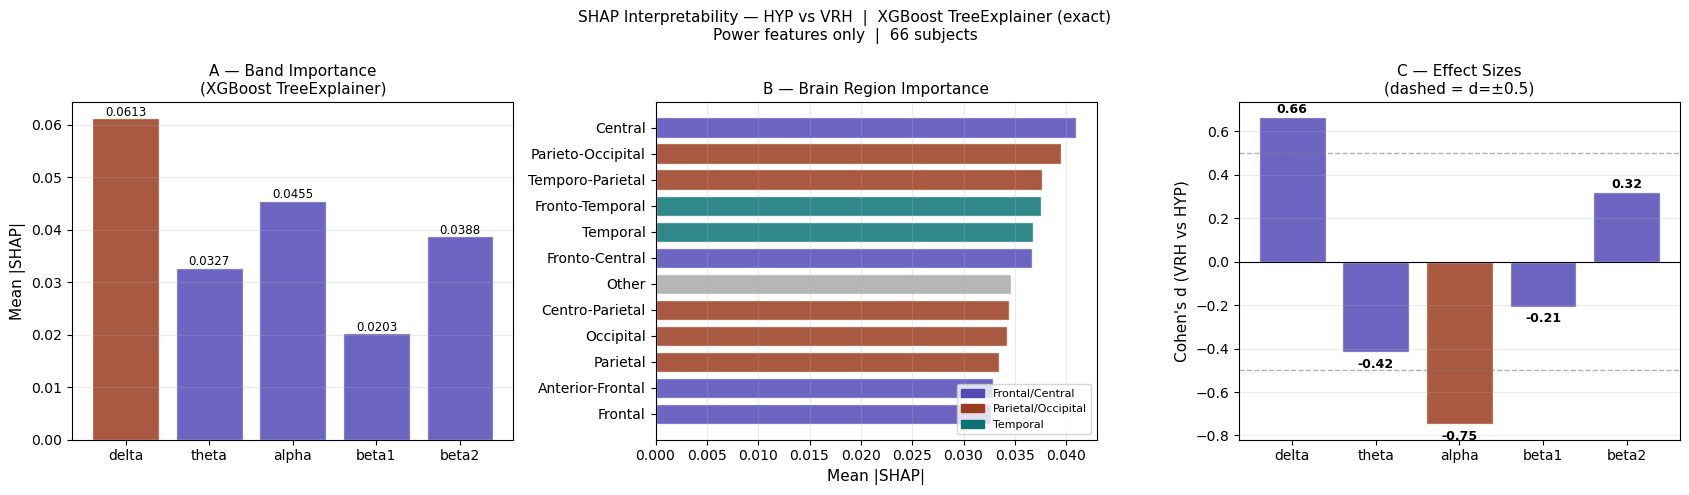

Figure 1 saved 


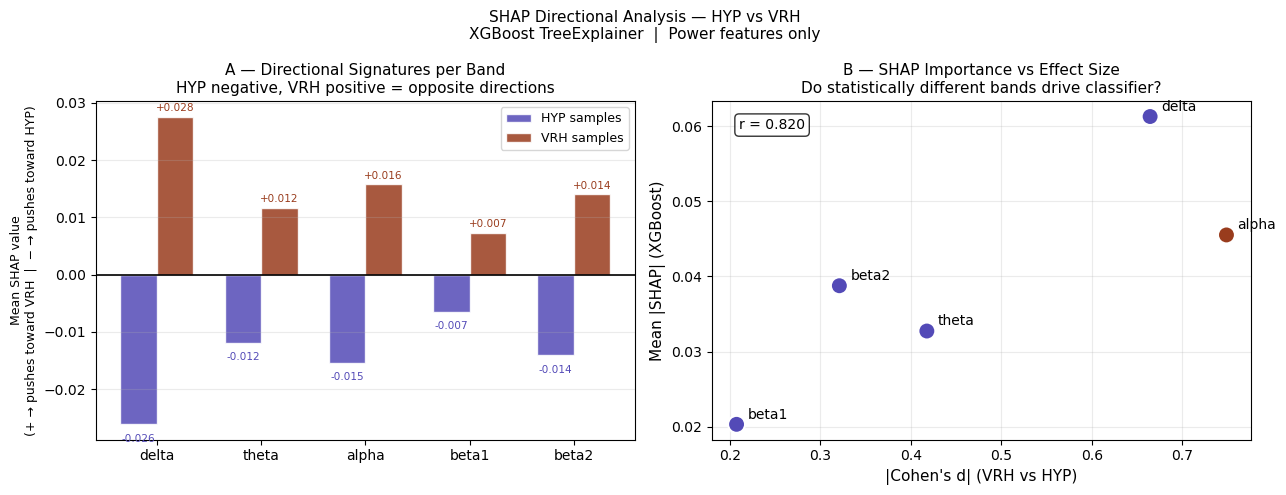

Figure 2 saved 


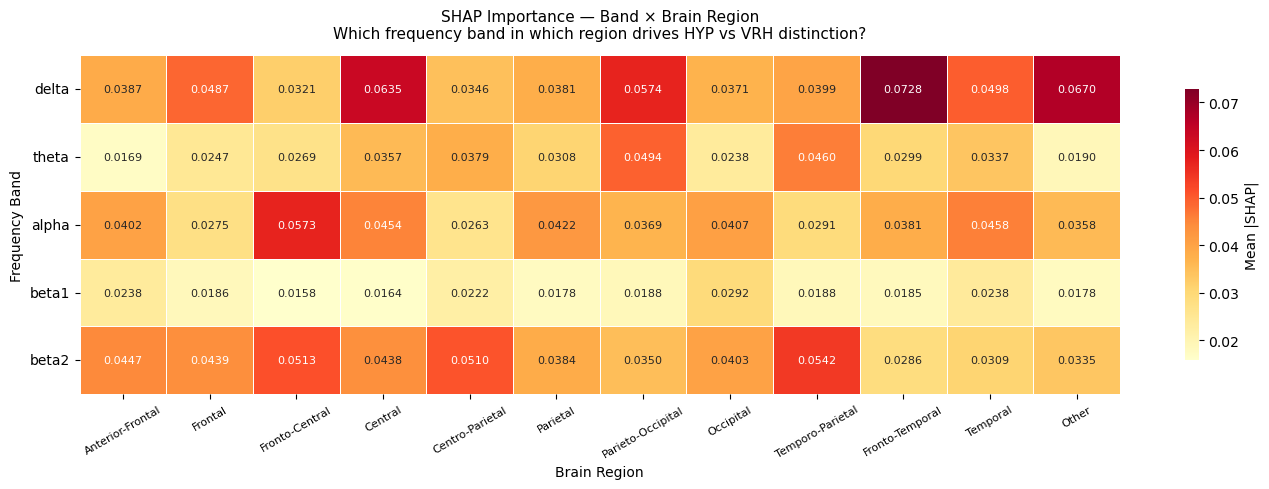

Figure 3 saved 

SHAP figures saved:
  fig_shap_summary.png
  fig_shap_directions.png
  fig_shap_band_region.png


In [23]:
# CELL — SHAP Visualisations
# ══════════════════════════════════════════════════════════════
# 3 figures:
#   1. Band importance + directional signatures + regions
#   2. Top channels bar chart
#   3. Per-band channel heatmap (band × region)
# ══════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════
# FIGURE 1 — Three-panel SHAP summary
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# -- Panel A — Band importance ---------------------------------
colors_bands = [
    C_VRH if v == band_importance.max()
    else C_HYP
    for v in band_importance]

axes[0].bar(BAND_NAMES, band_importance,
            color=colors_bands,
            alpha=0.85, edgecolor='white')
axes[0].set_ylabel('Mean |SHAP|', fontsize=11)
axes[0].set_title(
    'A — Band Importance\n(XGBoost TreeExplainer)',
    fontsize=11)
for i, v in enumerate(band_importance):
    axes[0].text(i, v + 0.0005,
                 f'{v:.4f}',
                 ha='center', fontsize=8.5)
axes[0].grid(True, axis='y', alpha=0.25)

# -- Panel B — Top 12 brain regions ---------------------------
def region_color(label):
    """Colour by anatomical region family."""
    if any(x in label for x in
           ['Parietal', 'Occipital']):
        return C_VRH
    if any(x in label for x in
           ['Frontal', 'Central']):
        return C_HYP
    if 'Temporal' in label:
        return C_SHARED
    return '#AAAAAA'

top12_reg = list(region_importance.keys())[:12]
top12_val = [region_importance[r] for r in top12_reg]
top12_col = [region_color(r) for r in top12_reg]

axes[1].barh(top12_reg, top12_val,
             color=top12_col,
             alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Mean |SHAP|', fontsize=11)
axes[1].set_title(
    'B — Brain Region Importance',
    fontsize=11)
axes[1].invert_yaxis()

patches = [
    mpatches.Patch(
        color=C_HYP,
        label='Frontal/Central'),
    mpatches.Patch(
        color=C_VRH,
        label='Parietal/Occipital'),
    mpatches.Patch(
        color=C_SHARED,
        label='Temporal'),
]
axes[1].legend(
    handles=patches, fontsize=8,
    loc='lower right')
axes[1].grid(True, axis='x', alpha=0.25)

# -- Panel C — Effect sizes (connects SHAP to stats) ----------
d_vrh_hyp = [
    cohens_d(
        log_bp[y==2, b, :].mean(axis=1),
        log_bp[y==1, b, :].mean(axis=1))
    for b in range(N_BANDS)]

bar_cols_d = [
    C_VRH if abs(d) == max(abs(x)
                           for x in d_vrh_hyp)
    else C_HYP
    for d in d_vrh_hyp]

axes[2].bar(BAND_NAMES, d_vrh_hyp,
            color=bar_cols_d,
            alpha=0.85, edgecolor='white')
axes[2].axhline(0, color='black', lw=0.8)
axes[2].axhline(0.5,  color='gray',
                linestyle='--', alpha=0.6, lw=1)
axes[2].axhline(-0.5, color='gray',
                linestyle='--', alpha=0.6, lw=1)
axes[2].set_ylabel(
    "Cohen's d (VRH vs HYP)", fontsize=11)
axes[2].set_title(
    'C — Effect Sizes\n(dashed = d=±0.5)',
    fontsize=11)
for i, d in enumerate(d_vrh_hyp):
    axes[2].text(
        i, d + (0.02 if d > 0 else -0.07),
        f'{d:.2f}', ha='center',
        fontsize=9, fontweight='bold')
axes[2].grid(True, axis='y', alpha=0.25)

plt.suptitle(
    f'SHAP Interpretability — HYP vs VRH  |  '
    f'XGBoost TreeExplainer (exact)\n'
    f'Power features only  |  '
    f'{len(np.unique(subjects))} subjects',
    fontsize=11)
plt.tight_layout()
plt.savefig('fig_shap_summary.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Figure 1 saved ')

# ══════════════════════════════════════════════════════════════
# FIGURE 2 — Directional signatures
# ══════════════════════════════════════════════════════════════
# Shows SHAP direction for HYP vs VRH samples per band.
# Key finding: all bands should show opposite directions —
# HYP negative (pushes toward HYP), VRH positive (toward VRH)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A — directional bar chart
hyp_dirs = [shap_3d[mask_hyp, b, :].mean()
            for b in range(N_BANDS)]
vrh_dirs = [shap_3d[mask_vrh, b, :].mean()
            for b in range(N_BANDS)]

x = np.arange(N_BANDS)
w = 0.35

axes[0].bar(x - w/2, hyp_dirs, w,
            color=C_HYP, alpha=0.85,
            label='HYP samples',
            edgecolor='white')
axes[0].bar(x + w/2, vrh_dirs, w,
            color=C_VRH, alpha=0.85,
            label='VRH samples',
            edgecolor='white')
axes[0].axhline(0, color='black', lw=1.2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(BAND_NAMES, fontsize=10)
axes[0].set_ylabel(
    'Mean SHAP value\n'
    '(+ → pushes toward VRH  |  − → pushes toward HYP)',
    fontsize=9)
axes[0].set_title(
    'A — Directional Signatures per Band\n'
    'HYP negative, VRH positive = opposite directions',
    fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y', alpha=0.25)

for i, (h, v) in enumerate(
        zip(hyp_dirs, vrh_dirs)):
    axes[0].text(
        i - w/2,
        h - 0.003 if h < 0 else h + 0.001,
        f'{h:+.3f}', ha='center',
        fontsize=7.5, color=C_HYP)
    axes[0].text(
        i + w/2,
        v + 0.001 if v > 0 else v - 0.003,
        f'{v:+.3f}', ha='center',
        fontsize=7.5, color=C_VRH)

# Panel B — SHAP importance vs effect size scatter
# Shows whether bands with high SHAP are the same
# bands with large statistical effect sizes
axes[1].scatter(
    np.abs(d_vrh_hyp), band_importance,
    c=[C_HYP, C_HYP, C_VRH, C_HYP, C_HYP],
    s=150, zorder=5,
    edgecolors='white', lw=1.5)

for i, band in enumerate(BAND_NAMES):
    axes[1].annotate(
        band,
        (abs(d_vrh_hyp[i]), band_importance[i]),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=10)

axes[1].set_xlabel(
    "|Cohen's d| (VRH vs HYP)", fontsize=11)
axes[1].set_ylabel(
    'Mean |SHAP| (XGBoost)', fontsize=11)
axes[1].set_title(
    'B — SHAP Importance vs Effect Size\n'
    'Do statistically different bands drive classifier?',
    fontsize=11)
axes[1].grid(True, alpha=0.25)

# correlation between SHAP and effect size
corr = np.corrcoef(
    np.abs(d_vrh_hyp), band_importance)[0, 1]
axes[1].text(
    0.05, 0.95,
    f'r = {corr:.3f}',
    transform=axes[1].transAxes,
    fontsize=10, va='top',
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='white', alpha=0.8))

plt.suptitle(
    'SHAP Directional Analysis — HYP vs VRH\n'
    'XGBoost TreeExplainer  |  Power features only',
    fontsize=11)
plt.tight_layout()
plt.savefig('fig_shap_directions.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Figure 2 saved ')

# ══════════════════════════════════════════════════════════════
# FIGURE 3 — Band × Region Heatmap
# ══════════════════════════════════════════════════════════════
# Which band-region combinations are most important?
# Rows = frequency bands, Columns = brain regions
# Cell = mean |SHAP| for that band-region combination

# compute band × region importance matrix
region_names = list(region_map.keys())
band_region_mat = np.zeros(
    (N_BANDS, len(region_names)))

for b in range(N_BANDS):
    for r_idx, (region, idxs) in enumerate(
            region_map.items()):
        valid = [i for i in idxs if i < N_CH]
        if valid:
            # project band b SHAP to channels
            # then take mean for this region
            band_region_mat[b, r_idx] = \
                ch_imp[b, valid].mean()

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    band_region_mat,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    xticklabels=region_names,
    yticklabels=BAND_NAMES,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Mean |SHAP|',
              'shrink': 0.8})

ax.set_title(
    'SHAP Importance — Band × Brain Region\n'
    'Which frequency band in which region '
    'drives HYP vs VRH distinction?',
    fontsize=11, pad=12)
ax.set_xlabel('Brain Region', fontsize=10)
ax.set_ylabel('Frequency Band', fontsize=10)
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig('fig_shap_band_region.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Figure 3 saved ')

print('\n' + '='*50)
print('SHAP figures saved:')
print('  fig_shap_summary.png')
print('  fig_shap_directions.png')
print('  fig_shap_band_region.png')
print('='*50)

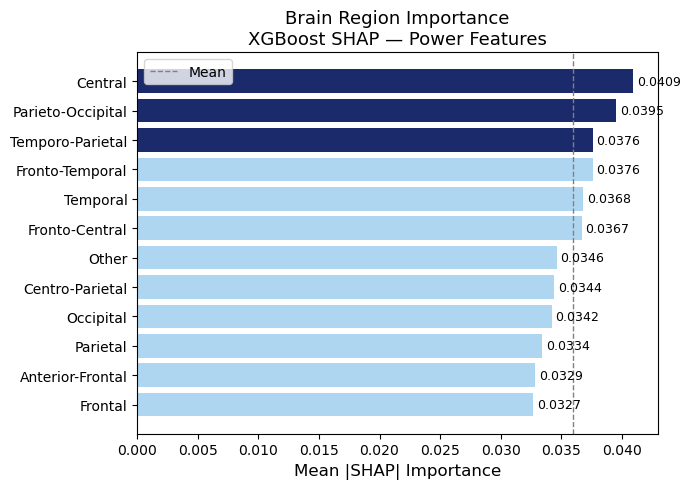

In [28]:
import matplotlib.pyplot as plt
import numpy as np

regions = [
    'Central', 'Parieto-Occipital', 'Temporo-Parietal', 'Fronto-Temporal',
    'Temporal', 'Fronto-Central', 'Other', 'Centro-Parietal',
    'Occipital', 'Parietal', 'Anterior-Frontal', 'Frontal'
]
importance = [
    0.040929, 0.039511, 0.037607, 0.037578,
    0.036811, 0.036675, 0.034627, 0.034402,
    0.034205, 0.033420, 0.032864, 0.032696
]

# Sort descending
idx = np.argsort(importance)
regions_sorted = [regions[i] for i in idx]
imp_sorted = [importance[i] for i in idx]

# Color: top 3 in navy, rest in pastel blue
colors = ['#1B2A6B' if i >= len(idx)-3 else '#AED6F1' for i in range(len(idx))]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(regions_sorted, imp_sorted, color=colors, edgecolor='none')

ax.set_xlabel('Mean |SHAP| Importance', fontsize=12)
ax.set_title('Brain Region Importance\nXGBoost SHAP — Power Features', fontsize=13)
ax.axvline(np.mean(imp_sorted), color='gray', linestyle='--', lw=1, label='Mean')
ax.legend(fontsize=10)

for bar, val in zip(bars, imp_sorted):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_shap_regions.png', dpi=150, bbox_inches='tight')
plt.show()